<>:528: SyntaxWarning: invalid escape sequence '\s'
<>:1739: SyntaxWarning: invalid escape sequence '\p'
<>:2802: SyntaxWarning: invalid escape sequence '\s'
<>:2881: SyntaxWarning: invalid escape sequence '\s'
<>:2883: SyntaxWarning: invalid escape sequence '\s'
<>:2892: SyntaxWarning: invalid escape sequence '\s'
<>:528: SyntaxWarning: invalid escape sequence '\s'
<>:1739: SyntaxWarning: invalid escape sequence '\p'
<>:2802: SyntaxWarning: invalid escape sequence '\s'
<>:2881: SyntaxWarning: invalid escape sequence '\s'
<>:2883: SyntaxWarning: invalid escape sequence '\s'
<>:2892: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2413/299129694.py:528: SyntaxWarning: invalid escape sequence '\s'
  log m_i^{PoU} pprox log 	ilde m_i - log \sum_j H(mu_i; j),
/tmp/ipykernel_2413/299129694.py:1739: SyntaxWarning: invalid escape sequence '\p'
  H_i(x) \propto exp[-0.5 (x - x_i)^T P_i (x - x_i)].
/tmp/ipykernel_2413/299129694.py:2802: SyntaxWarning: invalid escape sequence '\s'
  

Generating EIT configuration with 16 current patterns and 72 electrodes...
Total observations: 1152 (16 patterns x 72 electrodes)
Loaded source basis with 100 modes.
Truncated to 32 modes.
Saved 'data/Basis.csv' and 'data/obs_locations.csv'
Configuration generation complete.

Initializing JAX EIT Physics Engine...
Loaded Final Basis shape: (1024, 32)
Electrode indices shape: (72,)
Current patterns shape: (16, 124)
Boundary nodes: 124
EIT Physics Engine Loaded Successfully.
Forward map 'solve_forward' is ready. Input dim: 32, Output dim: 1152
Global Dtype set to: torch.float64
Device: cuda
--- Setting up 32D EIT Inverse Problem ---
Generating 5000 reference particles for the base bank...
Precomputing base reference bank with 5000 particles...
  [base] Calculating Likelihoods / Grads (batched)...
  [base] Calculating Hessians (batched)...
    [base] Hessian batch 0/5000...
    [base] Hessian batch 40/5000...
    [base] Hessian batch 80/5000...
    [base] Hessian batch 120/5000...
    [ba

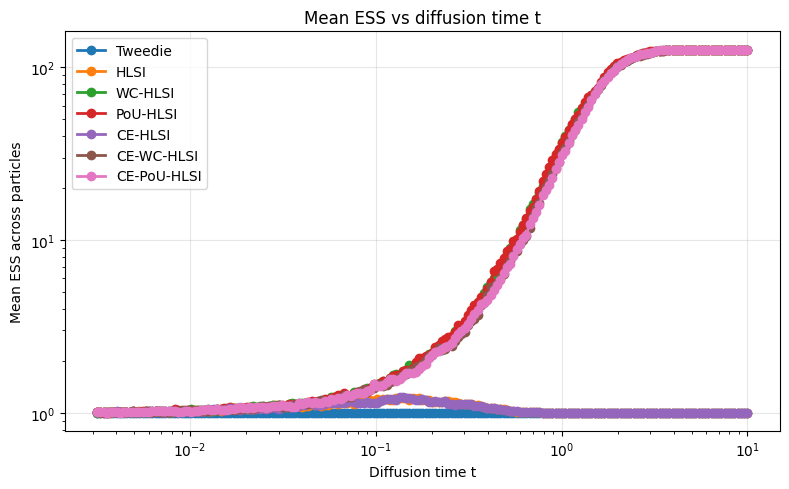


=== Evaluation (latent/coordinate metrics) ===
Method                   | RMSE_alpha | RelL2_alpha | MMD->Prior     | KSD        | KLdiag    
-----------------------------------------------------------------------------------------------
Prior                    | 0.3778     | 0.8029      | 0.0000         | 5.4340     | 603.4158  
Tweedie                  | 0.8599     | 1.8273      | 0.6381         | 175.8114   | 651.3614  
Blend                    | 0.4893     | 1.0399      | 0.3688         | 1209.4600  | 1072.3779 
HLSI                     | 0.4033     | 0.8571      | 0.2983         | 4.8001     | 577.8709  
WC-HLSI                  | 0.3758     | 0.7986      | 0.2939         | 5.7652     | 579.5597  
PoU-HLSI                 | 0.3685     | 0.7830      | 0.2891         | 6.0871     | 580.3689  
CE-HLSI                  | 0.3887     | 0.8260      | 0.3017         | 4.7989     | 578.0704  
CE-WC-HLSI               | 0.3863     | 0.8209      | 0.3024         | 5.1436     | 578.1215  
C

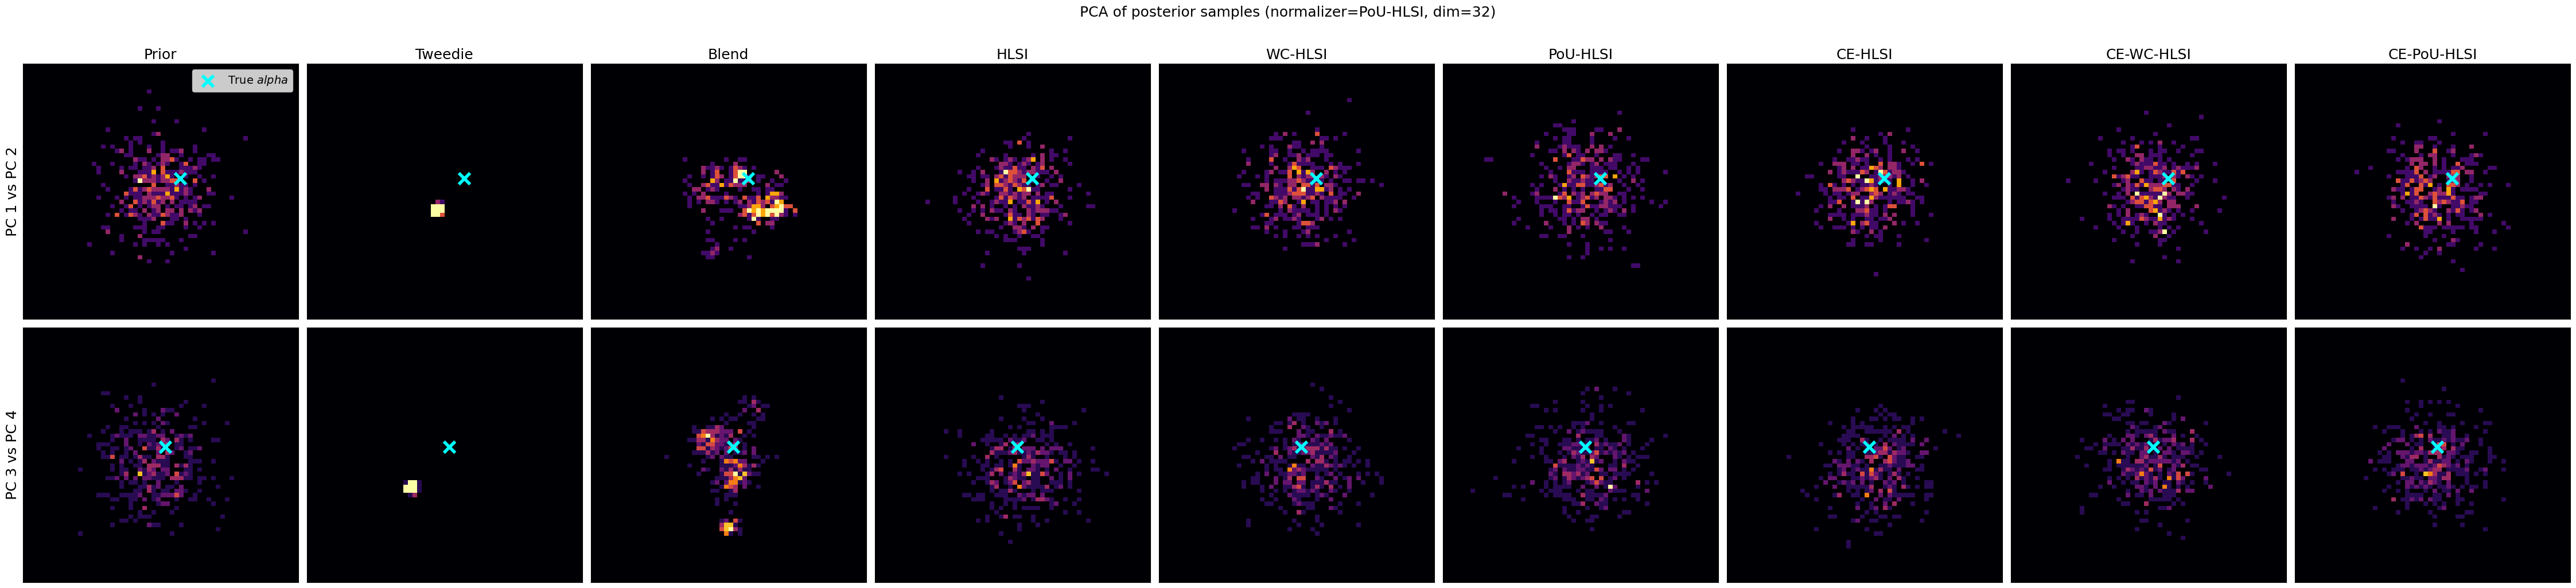


=== Final EIT metrics (paper-ready) ===
Method                   | RMSE_a    | RMSE_m    | FwdRel    | MMD->Prior   | KSD       | KLdiag   
--------------------------------------------------------------------------------------------------
Prior                    | 3.778e-01 | 2.073e-01 | 9.211e-02 | 0.000e+00    | 5.434e+00 | 6.034e+02
Tweedie                  | 8.599e-01 | 4.490e-01 | 1.263e-01 | 6.381e-01    | 1.758e+02 | 6.514e+02
Blend                    | 4.893e-01 | 2.926e-01 | 1.803e-01 | 3.688e-01    | 1.209e+03 | 1.072e+03
HLSI                     | 4.033e-01 | 2.074e-01 | 5.127e-02 | 2.983e-01    | 4.800e+00 | 5.779e+02
WC-HLSI                  | 3.758e-01 | 1.926e-01 | 5.235e-02 | 2.939e-01    | 5.765e+00 | 5.796e+02
PoU-HLSI                 | 3.685e-01 | 1.898e-01 | 5.138e-02 | 2.891e-01    | 6.087e+00 | 5.804e+02
CE-HLSI                  | 3.887e-01 | 2.010e-01 | 5.136e-02 | 3.017e-01    | 4.799e+00 | 5.781e+02
CE-WC-HLSI               | 3.863e-01 | 1.992e-01 | 5.170e-02

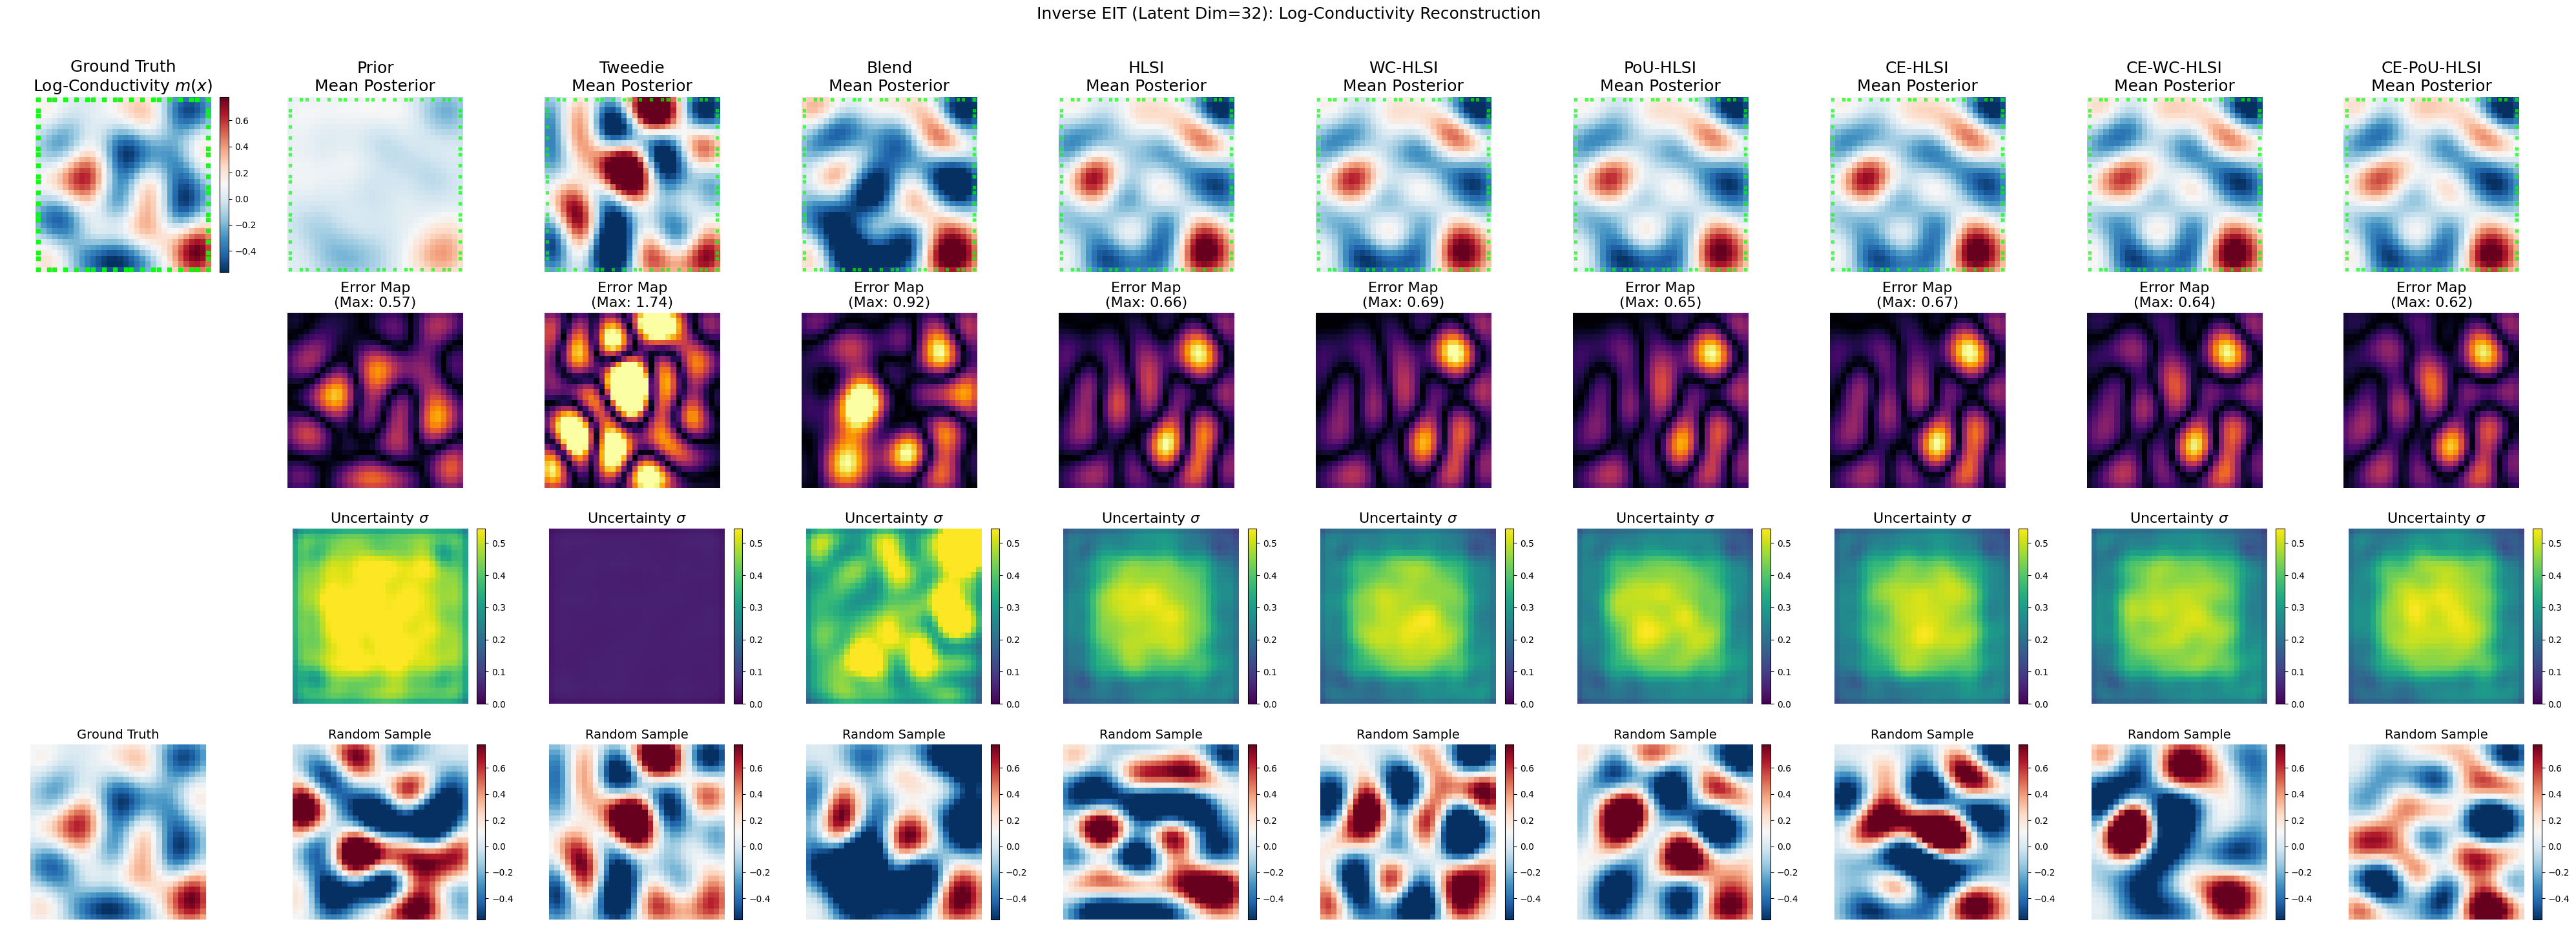


Visualizing Electric Potential Fields (Pattern 0)...


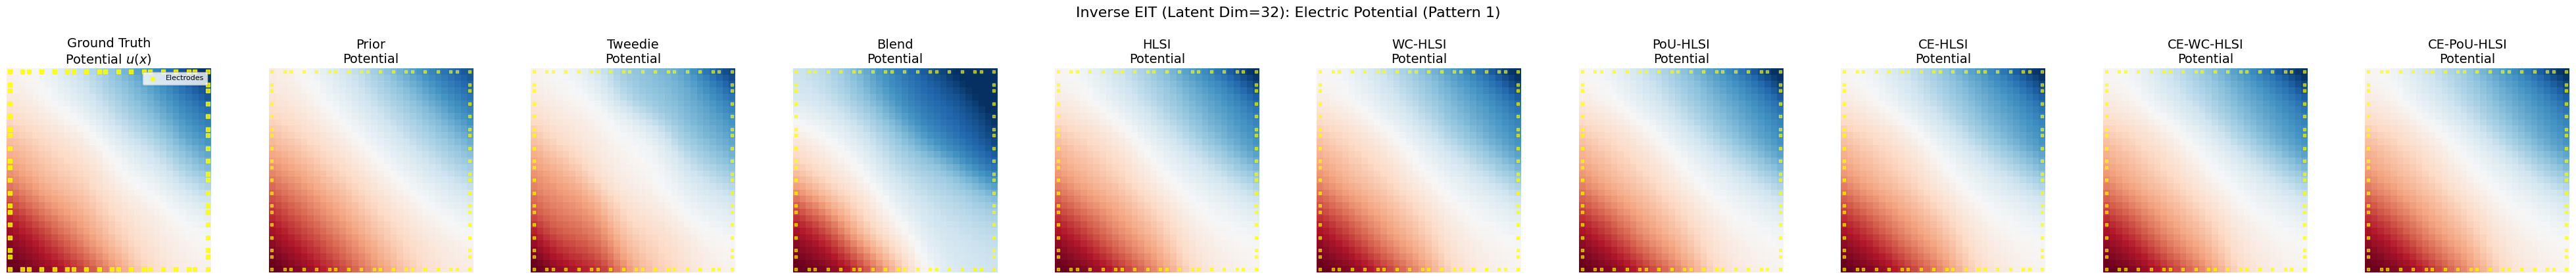


Visualizing Conductivity exp(m) Fields...


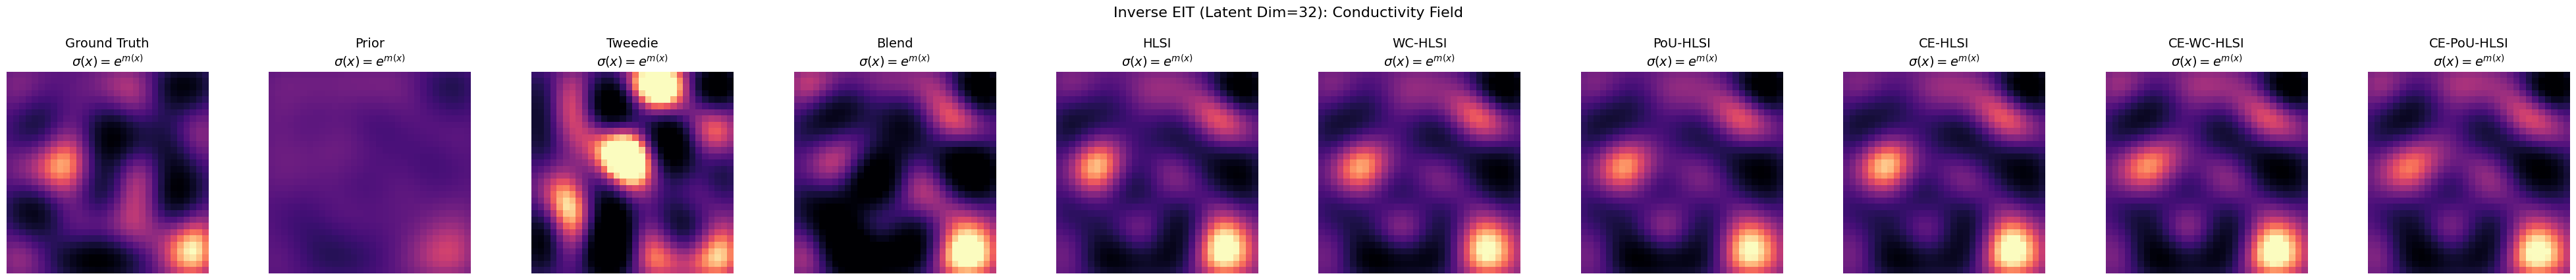


Visualizing Boundary Voltage Profiles (multiple patterns)...


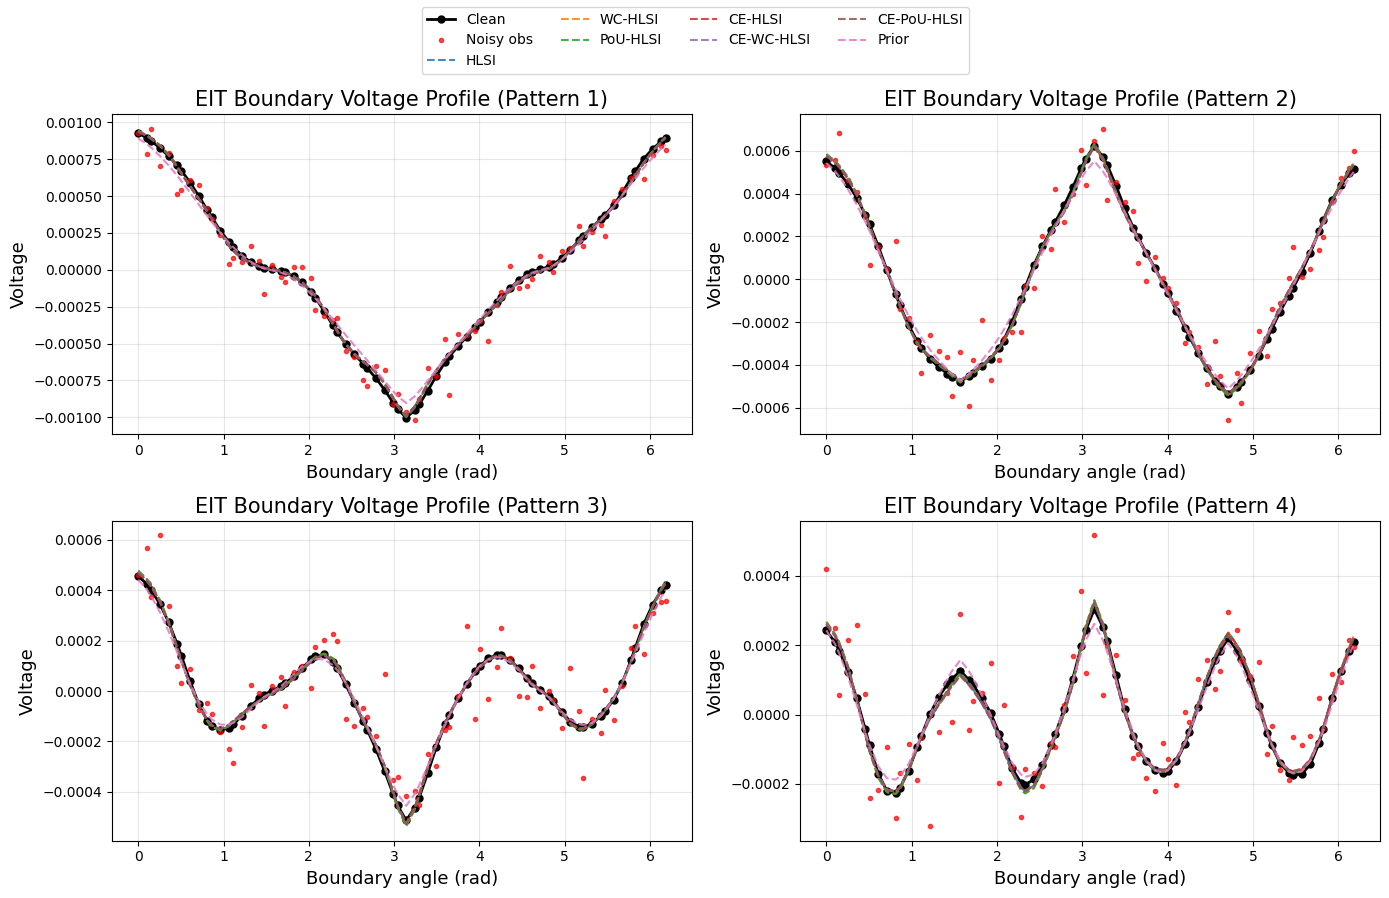


=== EIT HLSI Pipeline Complete ===


In [3]:


# -*- coding: utf-8 -*-
"""EIT_wc_ce_hlsi.py

Electrical Impedance Tomography (EIT) inverse problem with HLSI posterior sampling.

Adapted from Darcy_wc_ce_hlsi.py — only the physics layer (Sections 0–2) and
visualization (Section 13) are changed.  The HLSI core (Sections 3–9) is identical.

PDE:   -div( sigma(x) grad u(x) ) = 0   on [0,1]^2,  sigma * du/dn = g_l on boundary
Unknown:  log-conductivity field  m(x) = sum_i sqrt(lam_i) phi_i(x) alpha_i
          sigma(x) = exp(m(x))
Prior:    alpha ~ N(0, I)  (KL coefficients)
Data:     noisy boundary voltage measurements under L current patterns

The exponential sensitivity-decay of EIT with depth makes the Hessian
eigenspectrum span many more orders of magnitude than Darcy, providing a
much harder testbed for the HLSI estimator hierarchy.
"""

# ==========================================
# 0. KL BASIS GENERATION (same Matern-like prior as Darcy)
# ==========================================
import numpy as np
from scipy.spatial.distance import cdist
import os

os.makedirs('data', exist_ok=True)

N = 32
x = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, x)
coords = np.column_stack([X.ravel(), Y.ravel()])  # (1024, 2)

# Matern-like covariance: C(r) = sigma^2 * exp(-r/ell)
ell = 0.06      # correlation length (shorter → more high-freq content → harder for EIT)
sigma_prior = 1.0
dists = cdist(coords, coords)
C = sigma_prior**2 * np.exp(-dists / ell)

# Eigendecompose
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# KL modes: phi_i * sqrt(lambda_i), keep top q_max
q_max = 100
Basis_Modes = eigvecs[:, :q_max] * np.sqrt(eigvals[:q_max])
np.savetxt('data/EIT_Basis_Modes.csv', Basis_Modes, delimiter=',')


###################################################################################################################################

import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.20")
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from functools import partial

# ==========================================
# CONFIGURATION GENERATOR (EIT)
# ==========================================

N = 32
num_truncated_series = 32   # Latent dimension (KL modes)
seed = 42

# --- EIT experiment design ---
N_CURRENT_PATTERNS = 16     # More patterns saturate the observable subspace
N_ELECTRODES = 72            # Dense electrode coverage on boundary

print(f"Generating EIT configuration with {N_CURRENT_PATTERNS} current patterns "
      f"and {N_ELECTRODES} electrodes...")

# 1. Identify boundary nodes (ordered counterclockwise)
def _ordered_boundary_indices(n):
    """Return flat indices of boundary nodes, ordered CCW starting from (0,0)."""
    idx = []
    # Bottom row: (0, 0) to (0, n-1)
    for j in range(n):
        idx.append(0 * n + j)
    # Right col: (1, n-1) to (n-1, n-1)
    for i in range(1, n):
        idx.append(i * n + (n - 1))
    # Top row: (n-1, n-2) to (n-1, 0)
    for j in range(n - 2, -1, -1):
        idx.append((n - 1) * n + j)
    # Left col: (n-2, 0) to (1, 0)
    for i in range(n - 2, 0, -1):
        idx.append(i * n + 0)
    return np.array(idx)

boundary_indices_ordered = _ordered_boundary_indices(N)
n_boundary = len(boundary_indices_ordered)   # 4*(N-1) = 124

# 2. Select electrode positions (equally spaced along boundary)
electrode_spacing = n_boundary / N_ELECTRODES
electrode_boundary_pos = np.round(np.arange(N_ELECTRODES) * electrode_spacing).astype(int)
electrode_boundary_pos = np.clip(electrode_boundary_pos, 0, n_boundary - 1)
electrode_flat_indices = boundary_indices_ordered[electrode_boundary_pos]

# 3. Trigonometric current patterns on boundary
# theta_k = 2*pi * arc_position_k / perimeter
# g_l(theta) = cos(l * theta), l = 1, ..., L
# Enforce zero-mean: cos patterns are already zero-mean for l >= 1
boundary_theta = 2.0 * np.pi * np.arange(n_boundary) / n_boundary

current_patterns = np.zeros((N_CURRENT_PATTERNS, n_boundary))
for l in range(N_CURRENT_PATTERNS):
    current_patterns[l] = np.cos((l + 1) * boundary_theta)

# Observation: voltage at electrode positions for each pattern
# Total observations = N_CURRENT_PATTERNS * N_ELECTRODES
num_observation = N_CURRENT_PATTERNS * N_ELECTRODES
print(f"Total observations: {num_observation} ({N_CURRENT_PATTERNS} patterns x {N_ELECTRODES} electrodes)")

# 4. Load and Truncate Basis
dimension_of_PoI = N * N

try:
    df_modes = pd.read_csv('data/EIT_Basis_Modes.csv', header=None)
    if isinstance(df_modes.iloc[0, 0], str):
        df_modes = pd.read_csv('data/EIT_Basis_Modes.csv')

    modes_raw = df_modes.to_numpy().flatten().astype(np.float64)
    num_modes_available = modes_raw.size // dimension_of_PoI
    full_basis = modes_raw.reshape((dimension_of_PoI, num_modes_available))
    basis_truncated = full_basis[:, :num_truncated_series]

    print(f"Loaded source basis with {num_modes_available} modes.")
    print(f"Truncated to {num_truncated_series} modes.")

    pd.DataFrame(basis_truncated).to_csv('data/Basis.csv', index=False, header=False)
    pd.DataFrame(electrode_flat_indices).to_csv('data/obs_locations.csv', index=False, header=False)
    print("Saved 'data/Basis.csv' and 'data/obs_locations.csv'")

except FileNotFoundError:
    raise FileNotFoundError("Could not find 'data/EIT_Basis_Modes.csv'.")

print("Configuration generation complete.\n")


# ==========================================
# Hardware setup
# ==========================================
jax.config.update("jax_enable_x64", True)

print("Initializing JAX EIT Physics Engine...")

# ==========================================
# 1. LOAD PHYSICAL CONSTANTS & BASIS
# ==========================================

Basis = jnp.array(basis_truncated)
obs_locations = jnp.array(electrode_flat_indices, dtype=int)
current_patterns_jax = jnp.array(current_patterns)
boundary_indices_jax = jnp.array(boundary_indices_ordered, dtype=int)

print(f"Loaded Final Basis shape: {Basis.shape}")
print(f"Electrode indices shape: {obs_locations.shape}")
print(f"Current patterns shape: {current_patterns_jax.shape}")
print(f"Boundary nodes: {n_boundary}")


# ==========================================
# 2. DEFINE FORWARD SOLVER (EIT)
# ==========================================
# PDE:  -div( sigma(x) grad u ) = 0   on [0,1]^2
# BC:   sigma * du/dn = g_l on boundary  (Neumann, current injection)
# Gauge: u pinned at node 0.
#
# Discretization: 2nd-order finite differences with variable coefficient.
# Full N^2 x N^2 Neumann system with gauge pin.
# ==========================================

h = 1.0 / (N - 1)

# Precompute face-connectivity arrays for vectorized assembly
# X-faces: connect (i,j) to (i+1,j), i=0..N-2, j=0..N-1
_xface_left = (jnp.arange(N - 1)[:, None] * N + jnp.arange(N)[None, :]).ravel()
_xface_right = _xface_left + N

# Y-faces: connect (i,j) to (i,j+1), i=0..N-1, j=0..N-2
_yface_bot = (jnp.arange(N)[:, None] * N + jnp.arange(N - 1)[None, :]).ravel()
_yface_top = _yface_bot + 1

# Arc-length element for boundary flux integration
# Each boundary node "owns" a segment of length h (edge nodes) or h (corners own h/2+h/2=h)
_boundary_ds = h * jnp.ones(n_boundary)

# Gauge node: pin node 0 (corner (0,0))
_GAUGE_NODE = 0


def _assemble_eit_neumann(sigma_field):
    """
    Assemble the full N^2 x N^2 stiffness matrix for the Neumann problem
    -div(sigma grad u) = 0,  with gauge pin at node 0.

    Uses harmonic-averaged conductivity at cell faces, same as Darcy.
    """
    n_total = N * N
    h2 = h * h

    # Harmonic averages at cell faces
    sigma_xp = (2.0 * sigma_field[:-1, :] * sigma_field[1:, :] /
                (sigma_field[:-1, :] + sigma_field[1:, :] + 1e-30))
    sigma_yp = (2.0 * sigma_field[:, :-1] * sigma_field[:, 1:] /
                (sigma_field[:, :-1] + sigma_field[:, 1:] + 1e-30))

    kx = sigma_xp.ravel() / h2   # (N-1)*N face conductances
    ky = sigma_yp.ravel() / h2   # N*(N-1) face conductances

    A = jnp.zeros((n_total, n_total))

    # X-faces: connect _xface_left[f] to _xface_right[f]
    A = A.at[_xface_left, _xface_left].add(kx)
    A = A.at[_xface_right, _xface_right].add(kx)
    A = A.at[_xface_left, _xface_right].add(-kx)
    A = A.at[_xface_right, _xface_left].add(-kx)

    # Y-faces: connect _yface_bot[f] to _yface_top[f]
    A = A.at[_yface_bot, _yface_bot].add(ky)
    A = A.at[_yface_top, _yface_top].add(ky)
    A = A.at[_yface_bot, _yface_top].add(-ky)
    A = A.at[_yface_top, _yface_bot].add(-ky)

    # Gauge pin: replace row/col _GAUGE_NODE with identity
    A = A.at[_GAUGE_NODE, :].set(0.0)
    A = A.at[:, _GAUGE_NODE].set(0.0)
    A = A.at[_GAUGE_NODE, _GAUGE_NODE].set(1.0)

    return A


def _build_eit_rhs(current_pattern_boundary):
    """
    Build RHS vector for one current pattern.
    current_pattern_boundary: shape (n_boundary,) — current density g_l at boundary nodes.
    The variational form gives:  rhs_k = integral_{boundary} g_l * phi_k ds
    For FD on uniform grid: rhs[boundary_node_k] = g_l(k) * ds_k.
    """
    rhs = jnp.zeros(N * N)
    flux = current_pattern_boundary * _boundary_ds
    rhs = rhs.at[boundary_indices_jax].add(flux)
    # Gauge pin: rhs at gauge node = 0
    rhs = rhs.at[_GAUGE_NODE].set(0.0)
    return rhs


# Precompute RHS matrix (independent of alpha — never differentiated through)
_RHS_ALL_PATTERNS = jnp.stack(
    [_build_eit_rhs(current_patterns_jax[l]) for l in range(N_CURRENT_PATTERNS)],
    axis=1,
)   # (N^2, L)


@jax.jit
def solve_forward(alpha):
    """
    The Forward Map F(alpha) for EIT.
    Input:  alpha — KL coefficients, shape (q,)
    Output: y_pred — boundary voltages at electrodes for all current patterns,
                     shape (L * n_electrodes,)
    """
    # 1. Map KL coefficients to conductivity field
    log_sigma = jnp.reshape(Basis @ alpha, (N, N))
    sigma_field = jnp.exp(log_sigma)

    # 2. Assemble Neumann stiffness (same for all patterns)
    A = _assemble_eit_neumann(sigma_field)

    # 3. Solve all patterns simultaneously: A @ U = RHS  (RHS is constant)
    U = jnp.linalg.solve(A, _RHS_ALL_PATTERNS)   # (N^2, L)

    # 4. Extract electrode voltages and remove mean per pattern
    V = U[obs_locations, :]          # (n_electrodes, L)
    V = V - jnp.mean(V, axis=0, keepdims=True)
    return V.T.ravel()               # (L * n_electrodes,)


@jax.jit
def solve_single_pattern(alpha, pattern_idx):
    """Solve EIT for a single pattern, return full potential field."""
    log_sigma = jnp.reshape(Basis @ alpha, (N, N))
    sigma_field = jnp.exp(log_sigma)
    A = _assemble_eit_neumann(sigma_field)
    rhs = _build_eit_rhs(current_patterns_jax[pattern_idx])
    u = jnp.linalg.solve(A, rhs)
    return u.reshape(N, N)


print("EIT Physics Engine Loaded Successfully.")
print(f"Forward map 'solve_forward' is ready. "
      f"Input dim: {num_truncated_series}, Output dim: {num_observation}")


# ==========================================
# 3. BRIDGE: JAX PHYSICS -> PYTORCH SAMPLER
# ==========================================

import torch
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import time
import math

jax.config.update("jax_enable_x64", True)
torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Global Dtype set to: {torch.get_default_dtype()}")
print(f"Device: {device}")

# Configuration for EIT
ACTIVE_DIM = num_truncated_series   # Latent dimension (KL modes)
NOISE_STD = 0.0001                    # Realistic EIT noise (~0.01% of signal)
PLOT_NORMALIZER = 'best'    # sampler label/display name, or 'best'

# Hessian spectral band for HLSI
HESS_MIN = 1e-4
HESS_MAX = 1e6

# GNL settings
GNL_PILOT_N = 1024
GNL_STIFF_LAMBDA_CUT = HESS_MAX
GNL_USE_DOMINANT_PARTICLE_NEWTON = True


# A. Define JAX Likelihood Functions

@jax.jit
def eit_log_likelihood_jax(alpha_k, y_obs_jax, sigma):
    y_pred = solve_forward(alpha_k)
    resid = y_pred - y_obs_jax
    return -jnp.sum(resid ** 2) / (2.0 * sigma ** 2)

eit_grad_lik_jax = jax.jit(jax.grad(eit_log_likelihood_jax, argnums=0))

USE_GAUSS_NEWTON_HESSIAN = True

solve_forward_jac_jax = jax.jit(jax.jacfwd(solve_forward))

@jax.jit
def eit_hess_lik_gn_jax(alpha_k, y_obs_jax, sigma):
    J = solve_forward_jac_jax(alpha_k)
    return -(J.T @ J) / (sigma ** 2)

eit_hess_lik_exact_jax = jax.jit(jax.hessian(eit_log_likelihood_jax, argnums=0))

def eit_hess_lik_jax(alpha_k, y_obs_jax, sigma):
    if USE_GAUSS_NEWTON_HESSIAN:
        return eit_hess_lik_gn_jax(alpha_k, y_obs_jax, sigma)
    return eit_hess_lik_exact_jax(alpha_k, y_obs_jax, sigma)

# Use generic names so the HLSI core (which references these via the
# PhysicsLikelihood wrapper) doesn't need to change.
batch_log_lik  = jax.vmap(eit_log_likelihood_jax, in_axes=(0, None, None))
batch_grad_lik = jax.vmap(eit_grad_lik_jax,       in_axes=(0, None, None))
batch_hess_lik = jax.vmap(eit_hess_lik_jax,       in_axes=(0, None, None))


# With this helper:
def batch_hess_lik_python(x_np, y_obs_jax, sigma):
    return np.stack(
        [np.asarray(eit_hess_lik_jax(x_np[i], y_obs_jax, sigma))
         for i in range(x_np.shape[0])],
        axis=0,
    )

class PhysicsLikelihood:
    def __init__(self, y_obs_np, sigma):
        self.y_obs_jax = jnp.array(y_obs_np)
        self.sigma = float(sigma)

    def log_likelihood(self, x_torch):
        x_np = x_torch.detach().cpu().numpy()
        ll_jax = batch_log_lik(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(np.array(ll_jax), device=x_torch.device, dtype=torch.float64)

    def grad_log_likelihood(self, x_torch):
        x_np = x_torch.detach().cpu().numpy()
        grad_jax = batch_grad_lik(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(np.array(grad_jax), device=x_torch.device, dtype=torch.float64)

    def hess_log_likelihood(self, x_torch):
        x_np = np.asarray(x_torch.detach().cpu().numpy(), dtype=np.float64)
        hess_np = batch_hess_lik_python(x_np, self.y_obs_jax, self.sigma)
        return torch.tensor(hess_np, device=x_torch.device, dtype=torch.float64)

# ==========================================
# 4. PRIOR
# ==========================================
class GaussianPrior(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def sample(self, n):
        return torch.randn(n, self.dim, device=device)

    def log_prob(self, x):
        return -0.5 * torch.sum(x ** 2, dim=1) - (self.dim / 2.0) * math.log(2 * math.pi)

    def score0(self, x):
        return -x


def _batched_log_likelihood_only(lik_model, x, batch_size=256):
    chunks = []
    with torch.no_grad():
        for i in range(0, x.shape[0], batch_size):
            chunks.append(lik_model.log_likelihood(x[i:i + batch_size]))
    return torch.cat(chunks, dim=0)


def sample_gaussian_from_precision(mean, precision, n_samples, eps=1e-10):
    """Sample x ~ N(mean, precision^{-1}) for dense SPD precision."""
    evals, evecs = torch.linalg.eigh(precision)
    evals = torch.clamp(evals, min=eps)
    transform = evecs * torch.rsqrt(evals).unsqueeze(0)
    z = torch.randn(n_samples, mean.numel(), device=mean.device, dtype=mean.dtype)
    return mean.unsqueeze(0) + z @ transform.T


def build_gnl_factorization(prior_model, lik_model, pilot_n=GNL_PILOT_N,
                            stiff_lambda_cut=GNL_STIFF_LAMBDA_CUT,
                            use_dominant_particle_newton=GNL_USE_DOMINANT_PARTICLE_NEWTON):
    """
    Build the partially informed base law ṡp0 ∝ p0 * L_S from the GN factorization
    around a fixed expansion point x_star. The expansion point is chosen once using
    a pilot prior cloud, then reused for all downstream queries.
    """
    d = prior_model.dim
    I = torch.eye(d, device=device, dtype=torch.float64)

    print(f"Building GNL factorization with pilot cloud of {pilot_n} prior samples...")
    x_pilot = prior_model.sample(pilot_n)
    log_lik_pilot = _batched_log_likelihood_only(lik_model, x_pilot, batch_size=256)
    best_idx = int(torch.argmax(log_lik_pilot).item())
    x_anchor = x_pilot[best_idx].clone()

    if use_dominant_particle_newton:
        grad_anchor = lik_model.grad_log_likelihood(x_anchor.unsqueeze(0))[0]
        hess_anchor = lik_model.hess_log_likelihood(x_anchor.unsqueeze(0))[0]
        P_anchor = I - 0.5 * (hess_anchor + hess_anchor.T)
        s_post_anchor = prior_model.score0(x_anchor.unsqueeze(0))[0] + grad_anchor
        delta_anchor = torch.linalg.solve(P_anchor + 1e-6 * I, s_post_anchor)
        x_star = x_anchor + delta_anchor
    else:
        x_star = x_anchor

    J_star_np = np.array(solve_forward_jac_jax(np.array(x_star.detach().cpu().numpy())))
    J_star = torch.tensor(J_star_np, device=device, dtype=torch.float64)

    # Thin SVD J = U diag(s) V^T. The GN likelihood precision along v_k is s_k^2 / sigma^2.
    _, singvals, Vh = torch.linalg.svd(J_star, full_matrices=False)
    V = Vh.mT
    lik_prec = (singvals ** 2) / (lik_model.sigma ** 2)
    post_lam = 1.0 + lik_prec

    stiff_mask = post_lam > stiff_lambda_cut
    residual_mask = ~stiff_mask

    VS = V[:, stiff_mask]
    VG = V[:, residual_mask]
    stiff_lik_prec = lik_prec[stiff_mask]
    residual_lik_prec = lik_prec[residual_mask]

    if stiff_lik_prec.numel() > 0:
        stiff_update = VS @ torch.diag(stiff_lik_prec) @ VS.T
    else:
        stiff_update = torch.zeros((d, d), device=device, dtype=torch.float64)

    P_tilde0 = I + stiff_update
    mu_tilde0 = torch.linalg.solve(P_tilde0, stiff_update @ x_star)

    print(f"  expansion index={best_idx}, pilot max logL={log_lik_pilot[best_idx].item():.4f}")
    print(f"  ||x_anchor||={torch.norm(x_anchor).item():.4f}, ||x_star||={torch.norm(x_star).item():.4f}")
    print(f"  stiff absorbed directions: {int(stiff_mask.sum().item())}/{post_lam.numel()}")

    return {
        'x_anchor': x_anchor.detach().clone(),
        'x_star': x_star.detach().clone(),
        'J_star': J_star.detach().clone(),
        'singvals': singvals.detach().clone(),
        'V': V.detach().clone(),
        'lik_prec': lik_prec.detach().clone(),
        'post_lam': post_lam.detach().clone(),
        'stiff_mask': stiff_mask.detach().clone(),
        'residual_mask': residual_mask.detach().clone(),
        'VS': VS.detach().clone(),
        'VG': VG.detach().clone(),
        'stiff_lik_prec': stiff_lik_prec.detach().clone(),
        'residual_lik_prec': residual_lik_prec.detach().clone(),
        'P_tilde0': P_tilde0.detach().clone(),
        'mu_tilde0': mu_tilde0.detach().clone(),
        'stiff_lambda_cut': float(stiff_lambda_cut),
    }


def eval_gnl_residual_loglik(x, gnl_info):
    """Residual GN log-likelihood ℓ~(x) = log L_G(x) + log L_F(x), up to an additive constant."""
    VG = gnl_info['VG']
    residual_lik_prec = gnl_info['residual_lik_prec']
    x_star = gnl_info['x_star']
    if residual_lik_prec.numel() == 0:
        return torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
    centered = x - x_star.unsqueeze(0)
    proj = centered @ VG
    return -0.5 * torch.sum((proj ** 2) * residual_lik_prec.unsqueeze(0), dim=1)


POU_QUERY_BLOCK = 128
POU_REF_BLOCK = 512


def _compute_log_pou_overlap_penalty(X_ref, mu_ref, eigvecs, prec_eig, trusted,
                                     label='base', query_block=POU_QUERY_BLOCK,
                                     ref_block=POU_REF_BLOCK):
    """
    Practical PoU correction for the WC masses:

        log m_i^{PoU} pprox log 	ilde m_i - log \sum_j H(mu_i; j),

    where H(\cdot; j) is the local Gaussian window centered at x_j with the same
    band-gated precision used by the HLSI geometry. We only change the global
    mixing weights here; the particle-wise score signal remains whatever the
    sampler config selects (HLSI, CE-HLSI, etc.).
    """
    n_ref = X_ref.shape[0]
    work_device = X_ref.device
    work_dtype = X_ref.dtype

    eig_for_logdet = torch.where(trusted, torch.clamp(prec_eig, min=1e-30), torch.ones_like(prec_eig))
    log_window_norm = 0.5 * torch.sum(torch.log(eig_for_logdet), dim=1)

    print(f"  [{label}] Computing PoU overlap penalties with query_block={query_block}, ref_block={ref_block}...")
    t0_pou = time.time()

    log_overlap = torch.empty((n_ref,), device=work_device, dtype=work_dtype)
    n_query_blocks = (n_ref + query_block - 1) // query_block

    for qb, q0 in enumerate(range(0, n_ref, query_block)):
        q1 = min(q0 + query_block, n_ref)
        mu_block = mu_ref[q0:q1]
        block_max = torch.full((q1 - q0,), -float('inf'), device=work_device, dtype=work_dtype)
        block_sumexp = torch.zeros((q1 - q0,), device=work_device, dtype=work_dtype)

        for r0 in range(0, n_ref, ref_block):
            r1 = min(r0 + ref_block, n_ref)
            X_block = X_ref[r0:r1]
            V_block = eigvecs[r0:r1]
            lam_block = prec_eig[r0:r1]
            norm_block = log_window_norm[r0:r1]

            diff = mu_block.unsqueeze(1) - X_block.unsqueeze(0)
            proj = torch.einsum('qrd,rdk->qrk', diff, V_block)
            mahal = torch.sum((proj ** 2) * lam_block.unsqueeze(0), dim=2)
            log_H = norm_block.unsqueeze(0) - 0.5 * mahal

            local_max = torch.max(log_H, dim=1).values
            new_max = torch.maximum(block_max, local_max)
            block_sumexp = (
                block_sumexp * torch.exp(block_max - new_max)
                + torch.sum(torch.exp(log_H - new_max.unsqueeze(1)), dim=1)
            )
            block_max = new_max

            del X_block, V_block, lam_block, norm_block, diff, proj, mahal, log_H, local_max, new_max

        log_overlap[q0:q1] = block_max + torch.log(torch.clamp(block_sumexp, min=1e-300))

        if (qb + 1) % max(1, n_query_blocks // 10) == 0 or q1 == n_ref:
            print(f"    [{label}] PoU overlap block {qb + 1}/{n_query_blocks} complete")

        del mu_block, block_max, block_sumexp
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"  [{label}] PoU overlap time: {time.time() - t0_pou:.2f}s")
    return log_overlap

def _compute_log_pou_denom_grad_hess_at_points(points, X_ref, eigvecs, prec_eig, trusted,
                                              label='base', query_block=POU_QUERY_BLOCK,
                                              ref_block=POU_REF_BLOCK):
    """
    Evaluate the undiffused PoU denominator

        H̄(x) = sum_j H_j(x)

    together with its gradient and Hessian at a batch of query points.
    This is the Stage-A PoU object needed to build the PoU-adjusted local bank
        s_{i,0}^{PoU}, P_i^{PoU}, mu_i^{PoU}, m_i^{PoU}.
    """
    n_query, d = points.shape
    work_device = points.device
    work_dtype = points.dtype

    eig_for_logdet = torch.where(
        trusted, torch.clamp(prec_eig, min=1e-30), torch.ones_like(prec_eig)
    )
    log_window_norm = 0.5 * torch.sum(torch.log(eig_for_logdet), dim=1)

    print(f"  [{label}] Computing PoU denominator grad/Hess at query_block={query_block}, ref_block={ref_block}...")
    t0_pou = time.time()

    log_denom = torch.empty((n_query,), device=work_device, dtype=work_dtype)
    grad_log_denom = torch.empty((n_query, d), device=work_device, dtype=work_dtype)
    hess_log_denom = torch.empty((n_query, d, d), device=work_device, dtype=work_dtype)
    n_query_blocks = (n_query + query_block - 1) // query_block

    for qb, q0 in enumerate(range(0, n_query, query_block)):
        q1 = min(q0 + query_block, n_query)
        x_block = points[q0:q1]
        qsz = q1 - q0
        block_max = torch.full((qsz,), -float('inf'), device=work_device, dtype=work_dtype)
        block_sumexp = torch.zeros((qsz,), device=work_device, dtype=work_dtype)
        block_grad_num = torch.zeros((qsz, d), device=work_device, dtype=work_dtype)
        block_second_num = torch.zeros((qsz, d, d), device=work_device, dtype=work_dtype)

        for r0 in range(0, X_ref.shape[0], ref_block):
            r1 = min(r0 + ref_block, X_ref.shape[0])
            X_block = X_ref[r0:r1]
            V_block = eigvecs[r0:r1]
            lam_block = prec_eig[r0:r1]
            norm_block = log_window_norm[r0:r1]

            diff = x_block.unsqueeze(1) - X_block.unsqueeze(0)                       # [q, r, d]
            proj = torch.einsum('qrd,rdk->qrk', diff, V_block)                       # [q, r, d]
            mahal = torch.sum((proj ** 2) * lam_block.unsqueeze(0), dim=2)           # [q, r]
            log_H = norm_block.unsqueeze(0) - 0.5 * mahal                            # [q, r]

            scaled_proj = proj * lam_block.unsqueeze(0)
            grad_log_H = -torch.einsum('qrk,rdk->qrd', scaled_proj, V_block)         # [q, r, d]

            P_block = torch.einsum('rij,rj,rkj->rik', V_block, lam_block, V_block)   # [r, d, d]
            hess_log_H = -P_block                                                    # [r, d, d]
            second_term = hess_log_H.unsqueeze(0) + torch.einsum('qri,qrj->qrij', grad_log_H, grad_log_H)

            local_max = torch.max(log_H, dim=1).values
            new_max = torch.maximum(block_max, local_max)
            rescale_old = torch.exp(block_max - new_max)
            weights = torch.exp(log_H - new_max.unsqueeze(1))

            block_sumexp = rescale_old * block_sumexp + torch.sum(weights, dim=1)
            block_grad_num = rescale_old.unsqueeze(1) * block_grad_num + torch.einsum(
                'qr,qrd->qd', weights, grad_log_H
            )
            block_second_num = rescale_old.unsqueeze(-1).unsqueeze(-1) * block_second_num + torch.einsum(
                'qr,qrij->qij', weights, second_term
            )
            block_max = new_max

            del X_block, V_block, lam_block, norm_block
            del diff, proj, mahal, log_H, scaled_proj, grad_log_H, P_block, hess_log_H, second_term
            del local_max, new_max, rescale_old, weights

        block_sumexp = torch.clamp(block_sumexp, min=1e-300)
        grad = block_grad_num / block_sumexp.unsqueeze(1)
        second = block_second_num / block_sumexp.unsqueeze(-1).unsqueeze(-1)

        log_denom[q0:q1] = block_max + torch.log(block_sumexp)
        grad_log_denom[q0:q1] = grad
        hess_log_denom[q0:q1] = second - torch.einsum('qi,qj->qij', grad, grad)

        if (qb + 1) % max(1, n_query_blocks // 10) == 0 or q1 == n_query:
            print(f"    [{label}] PoU denominator grad/Hess block {qb + 1}/{n_query_blocks} complete")

        del x_block, block_max, block_sumexp, block_grad_num, block_second_num
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"  [{label}] PoU denominator grad/Hess time: {time.time() - t0_pou:.2f}s")
    return log_denom, grad_log_denom, hess_log_denom


def _compute_log_pou_denom_and_grad_at_points(points, X_ref, eigvecs, prec_eig, trusted,
                                              label='base', query_block=POU_QUERY_BLOCK,
                                              ref_block=POU_REF_BLOCK):
    log_denom, grad_log_denom, _ = _compute_log_pou_denom_grad_hess_at_points(
        points, X_ref, eigvecs, prec_eig, trusted,
        label=label, query_block=query_block, ref_block=ref_block,
    )
    return log_denom, grad_log_denom

def precompute_reference_bank(X_ref, prior_model, lik_model, label='base',
                              residual_log_weights=None, compute_pou=True,
                              pou_query_block=POU_QUERY_BLOCK,
                              pou_ref_block=POU_REF_BLOCK):
    """
    Precompute the local posterior HLSI objects on a fixed reference bank.
    In Stage-A PoU mode we also build a PoU-adjusted local bank with
        s_{i,0}^{PoU}, P_i^{PoU}, mu_i^{PoU}, m_i^{PoU},
    so PoU-HLSI / CE-PoU-HLSI use PoU-adjusted local geometry rather than
    the old base bank plus a query-time denominator subtraction.
    """
    print(f"Precomputing {label} reference bank with {X_ref.shape[0]} particles...")
    t0_bank = time.time()

    with torch.no_grad():
        s0_prior = prior_model.score0(X_ref)
        log_prior = prior_model.log_prob(X_ref)

        BATCH_LIK = 50
        BATCH_HESS = 2

        print(f"  [{label}] Calculating Likelihoods / Grads (batched)...")
        log_lik_list = []
        grad_lik_list = []
        for i in range(0, X_ref.shape[0], BATCH_LIK):
            batch = X_ref[i:i + BATCH_LIK]
            log_lik_list.append(lik_model.log_likelihood(batch))
            grad_lik_list.append(lik_model.grad_log_likelihood(batch))
        log_lik = torch.cat(log_lik_list, dim=0)
        grad_lik = torch.cat(grad_lik_list, dim=0)

        print(f"  [{label}] Calculating Hessians (batched)...")
        hess_lik_list = []
        for i in range(0, X_ref.shape[0], BATCH_HESS):
            if i % (BATCH_HESS * 20) == 0:
                print(f"    [{label}] Hessian batch {i}/{X_ref.shape[0]}...")
            batch = X_ref[i:i + BATCH_HESS]
            hess_lik_list.append(lik_model.hess_log_likelihood(batch))
        hess_lik = torch.cat(hess_lik_list, dim=0)

        s0_post = s0_prior + grad_lik

        d = X_ref.shape[1]
        I = torch.eye(d, device=device, dtype=torch.float64).unsqueeze(0)
        P_raw = I - hess_lik
        P_raw = 0.5 * (P_raw + P_raw.transpose(-1, -2))

        print(f"  [{label}] Spectral band gating: [{HESS_MIN:.1e}, {HESS_MAX:.1e}]")
        eigvals, eigvecs = torch.linalg.eigh(P_raw)
        trusted = (eigvals >= HESS_MIN) & (eigvals <= HESS_MAX)

        n_below = (eigvals < HESS_MIN).float().sum(dim=1).mean().item()
        n_above = (eigvals > HESS_MAX).float().sum(dim=1).mean().item()
        n_band = trusted.float().sum(dim=1).mean().item()
        print(f"    [{label}] mean {n_band:.1f} in-band, {n_below:.1f} too-sloppy, {n_above:.1f} too-stiff (of {d})")

        prec_eig = torch.where(trusted, eigvals, torch.zeros_like(eigvals))
        P_ref = torch.einsum('nij,nj,nkj->nik', eigvecs, prec_eig, eigvecs)
        P_ref = P_ref + 1e-6 * I

        s_eig = (eigvecs.mT @ s0_post.unsqueeze(-1)).squeeze(-1)
        delta_eig = torch.where(
            trusted,
            s_eig / torch.clamp(prec_eig, min=HESS_MIN),
            torch.zeros_like(s_eig),
        )
        delta = (eigvecs @ delta_eig.unsqueeze(-1)).squeeze(-1)
        mu_ref = X_ref + delta

        gated_info = {
            'eigvecs': eigvecs,
            'eigvals': prec_eig,
            'trusted': trusted,
        }

        log_post_x = log_prior + log_lik
        quad_gain = 0.5 * torch.sum(s0_post * delta, dim=1)
        eig_for_logdet = torch.where(trusted, eigvals, torch.ones_like(eigvals))
        logdet_P = torch.sum(torch.log(torch.clamp(eig_for_logdet, min=1e-30)), dim=1)
        log_mass = (log_post_x + quad_gain) - 0.5 * logdet_P

        log_pou = None
        log_window_overlap = None
        log_pou_denom_ref = None
        grad_log_pou_denom_ref = None
        hess_log_pou_denom_ref = None
        s0_pou = None
        P_pou_ref = None
        mu_pou_ref = None
        gated_info_pou = None
        if compute_pou:
            log_window_norm = 0.5 * torch.sum(torch.log(torch.clamp(eig_for_logdet, min=1e-30)), dim=1)
            P_window_ref = torch.einsum('nij,nj,nkj->nik', eigvecs, prec_eig, eigvecs)

            log_pou_denom_ref, grad_log_pou_denom_ref, hess_log_pou_denom_ref = _compute_log_pou_denom_grad_hess_at_points(
                X_ref, X_ref, eigvecs, prec_eig, trusted,
                label=label, query_block=pou_query_block, ref_block=pou_ref_block,
            )

            s0_pou = s0_post - grad_log_pou_denom_ref
            # For q_i^*(x) = pi(x) H_i(x) / Hbar(x),
            #   -∇² log q_i^* = P_post + P_window + ∇² log Hbar.
            # The denominator Hessian therefore enters with a plus sign.
            P_pou_raw = P_raw + P_window_ref + hess_log_pou_denom_ref
            P_pou_raw = 0.5 * (P_pou_raw + P_pou_raw.transpose(-1, -2))

            eigvals_pou, eigvecs_pou = torch.linalg.eigh(P_pou_raw)
            trusted_pou = (eigvals_pou >= HESS_MIN) & (eigvals_pou <= HESS_MAX)
            prec_eig_pou = torch.where(trusted_pou, eigvals_pou, torch.zeros_like(eigvals_pou))
            P_pou_ref = torch.einsum('nij,nj,nkj->nik', eigvecs_pou, prec_eig_pou, eigvecs_pou) + 1e-6 * I

            s0_pou_eig = torch.einsum('nij,nj->ni', eigvecs_pou.transpose(-1, -2), s0_pou)
            delta_pou_eig = torch.where(
                trusted_pou,
                s0_pou_eig / torch.clamp(prec_eig_pou, min=HESS_MIN),
                torch.zeros_like(s0_pou_eig),
            )
            delta_pou = torch.einsum('nij,nj->ni', eigvecs_pou, delta_pou_eig)
            mu_pou_ref = X_ref + delta_pou

            gated_info_pou = {
                'eigvecs': eigvecs_pou,
                'eigvals': prec_eig_pou,
                'trusted': trusted_pou,
            }

            quad_gain_pou = 0.5 * torch.sum(s0_pou * delta_pou, dim=1)
            eig_for_logdet_pou = torch.where(trusted_pou, eigvals_pou, torch.ones_like(eigvals_pou))
            logdet_P_pou = torch.sum(torch.log(torch.clamp(eig_for_logdet_pou, min=1e-30)), dim=1)
            log_pou = (log_post_x + log_window_norm - log_pou_denom_ref + quad_gain_pou) - 0.5 * logdet_P_pou
            log_window_overlap = log_pou_denom_ref

        norm_prior = torch.norm(s0_prior, dim=1).mean().item()
        norm_lik = torch.norm(grad_lik, dim=1).mean().item()
        avg_ll = log_lik.mean().item()
        print(f"  [{label}] Avg Prior Score Norm:     {norm_prior:.4f}")
        print(f"  [{label}] Avg Likelihood Grad Norm: {norm_lik:.4f}")
        print(f"  [{label}] Avg Log-Likelihood:       {avg_ll:.4f}")

        bank = {
            'X_ref': X_ref.detach().cpu(),
            's0_post_ref': s0_post.detach().cpu(),
            'log_lik_ref': log_lik.detach().cpu(),
            'log_mass_ref': log_mass.detach().cpu(),
            'P_ref': P_ref.detach().cpu(),
            'mu_ref': mu_ref.detach().cpu(),
            'gated_info': {k: v.detach().cpu() for k, v in gated_info.items()},
        }
        if log_pou is not None:
            bank['s0_pou_ref'] = s0_pou.detach().cpu()
            bank['log_pou_ref'] = log_pou.detach().cpu()
            bank['log_window_overlap_ref'] = log_window_overlap.detach().cpu()
            bank['log_pou_denom_ref'] = log_pou_denom_ref.detach().cpu()
            bank['grad_log_pou_denom_ref'] = grad_log_pou_denom_ref.detach().cpu()
            bank['hess_log_pou_denom_ref'] = hess_log_pou_denom_ref.detach().cpu()
            bank['P_pou_ref'] = P_pou_ref.detach().cpu()
            bank['mu_pou_ref'] = mu_pou_ref.detach().cpu()
            bank['gated_info_pou'] = {k: v.detach().cpu() for k, v in gated_info_pou.items()}
        if residual_log_weights is not None:
            bank['log_lik_res_ref'] = residual_log_weights.detach().cpu()

    print(f"  [{label}] Precomputation time: {time.time() - t0_bank:.2f}s")

    del s0_prior, log_prior, log_lik, grad_lik, hess_lik, s0_post
    del P_raw, eigvals, eigvecs, trusted, prec_eig, delta, P_ref, mu_ref, gated_info
    del log_post_x, quad_gain, eig_for_logdet, logdet_P, I, log_mass
    if log_pou is not None:
        del log_pou, log_window_overlap, log_pou_denom_ref, grad_log_pou_denom_ref, hess_log_pou_denom_ref
        del s0_pou, P_pou_ref, mu_pou_ref, gated_info_pou
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return bank


# ==========================================
# 5. SAMPLERS (physics-agnostic — updated to stream reference chunks)
# ==========================================

REF_STREAM_BATCH = 512


def _canonicalize_time(t):
    t_val = t.item() if isinstance(t, torch.Tensor) else float(t)
    return max(t_val, 1e-4)


def _streaming_max_logw(y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=REF_STREAM_BATCH):
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    var_t = 1.0 - math.exp(-2.0 * t_val)

    m_query = y.shape[0]
    n_ref = X_ref_cpu.shape[0]
    max_log_w = torch.full((m_query,), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        current_max = torch.max(log_w_batch, dim=1).values
        max_log_w = torch.maximum(max_log_w, current_max)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch, current_max

    return t_val, et, var_t, max_log_w


def get_posterior_snis_weights(y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=REF_STREAM_BATCH):
    """
    Memory-safe two-pass SNIS weights. This still materializes the final [M, N]
    weight matrix, but avoids the catastrophic [M, N, d] allocation.
    """
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    chunks = []
    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w_batch - max_log_w.unsqueeze(1))
        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        chunks.append(w_batch)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch

    w = torch.cat(chunks, dim=1)
    return w / torch.clamp(denom_Z, min=1e-30)


def eval_blend_posterior_score(y, t, X_ref_cpu, s0_post_ref_cpu, log_lik_ref_cpu,
                               batch_size=REF_STREAM_BATCH):
    return eval_score_batched(
        y, t, X_ref_cpu, s0_post_ref_cpu, log_lik_ref_cpu,
        batch_size=batch_size, mode='blend_posterior')


def eval_score_batched(y, t, X_ref_cpu, s0_ref_cpu, log_lik_ref_cpu,
                       batch_size=REF_STREAM_BATCH, mode='blend_posterior'):
    """
    Streaming batched Tweedie / Blend Posterior score to avoid OOM.
    X_ref_cpu / s0_ref_cpu / log_lik_ref_cpu are expected to live on CPU.
    """
    t_val = _canonicalize_time(t)

    et = math.exp(-t_val)
    var_t = 1.0 - math.exp(-2 * t_val)
    inv_v = 1.0 / var_t
    scale_factor = 1.0 / et

    m_query = y.shape[0]
    n_ref = X_ref_cpu.shape[0]

    # --- PASS 1: Find Global Max Log-Weight ---
    max_log_w = torch.full((m_query,), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        dists_sq = torch.sum((y.unsqueeze(1) - mus.unsqueeze(0)) ** 2, dim=2)
        log_w_batch = -dists_sq / (2 * var_t) + ll_batch.unsqueeze(0)
        current_max = torch.max(log_w_batch, dim=1).values
        max_log_w = torch.maximum(max_log_w, current_max)
        del X_batch, ll_batch, mus, dists_sq, log_w_batch, current_max

    # --- PASS 2: Accumulate Moments ---
    denom_Z = torch.zeros((m_query, 1), device=y.device, dtype=y.dtype)
    numer_mu_x = torch.zeros_like(y)

    if mode == 'blend_posterior':
        numer_s0 = torch.zeros_like(y)
        acc_w2 = torch.zeros((m_query, 1), device=y.device, dtype=y.dtype)
        acc_w2_s0_norm = torch.zeros((m_query,), device=y.device, dtype=y.dtype)
        acc_w2_s0 = torch.zeros_like(y)
        acc_w2_x = torch.zeros_like(y)
        acc_w2_x_norm = torch.zeros((m_query,), device=y.device, dtype=y.dtype)
        acc_w2_dot = torch.zeros((m_query,), device=y.device, dtype=y.dtype)

    for i in range(0, n_ref, batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        dists_sq = torch.sum((y.unsqueeze(1) - mus.unsqueeze(0)) ** 2, dim=2)
        log_w = -dists_sq / (2 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w - max_log_w.unsqueeze(1))

        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        numer_mu_x += torch.einsum('mb,bd->md', w_batch, X_batch)

        if mode == 'blend_posterior':
            s0_batch = s0_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
            numer_s0 += torch.einsum('mb,bd->md', w_batch, s0_batch)

            w2_batch = w_batch ** 2
            acc_w2 += torch.sum(w2_batch, dim=1, keepdim=True)
            s0_sq_batch = torch.sum(s0_batch ** 2, dim=1)
            x_sq_batch = torch.sum(X_batch ** 2, dim=1)
            dot_batch = torch.sum(s0_batch * X_batch, dim=1)

            acc_w2_s0_norm += torch.mv(w2_batch, s0_sq_batch)
            acc_w2_s0 += torch.mm(w2_batch, s0_batch)
            acc_w2_x += torch.mm(w2_batch, X_batch)
            acc_w2_x_norm += torch.mv(w2_batch, x_sq_batch)
            acc_w2_dot += torch.mv(w2_batch, dot_batch)
            del s0_batch, w2_batch, s0_sq_batch, x_sq_batch, dot_batch

        del X_batch, ll_batch, mus, dists_sq, log_w, w_batch

    # --- FINALIZE ---
    eps = 1e-12
    mu_x = numer_mu_x / denom_Z
    score_twd = -inv_v * (y - et * mu_x)

    if mode == 'tweedie':
        return score_twd

    Z_sq = denom_Z ** 2
    mu_a = scale_factor * (numer_s0 / denom_Z)
    mu_b = score_twd
    S0 = acc_w2 / Z_sq

    S1a = (scale_factor ** 2) * (acc_w2_s0_norm.unsqueeze(1) / Z_sq)
    S2a = scale_factor * (acc_w2_s0 / Z_sq)

    den_sn = torch.clamp(1.0 - S0, min=eps)
    mu_a_norm2 = torch.sum(mu_a ** 2, dim=1, keepdim=True)
    num_Vk = S1a - 2.0 * torch.sum(mu_a * S2a, dim=1, keepdim=True) + mu_a_norm2 * S0
    Vk = num_Vk / den_sn

    term_w2_x = acc_w2_x / Z_sq
    S2b = -inv_v * (y * S0 - et * term_w2_x)
    y_norm2 = torch.sum(y ** 2, dim=1, keepdim=True)
    y_dot_w2x = torch.sum(y * term_w2_x, dim=1, keepdim=True)
    term_w2_x_norm = acc_w2_x_norm.unsqueeze(1) / Z_sq
    S1b = (inv_v ** 2) * (y_norm2 * S0 - 2.0 * et * y_dot_w2x + (et ** 2) * term_w2_x_norm)
    mu_b_norm2 = torch.sum(mu_b ** 2, dim=1, keepdim=True)
    num_Vt = S1b - 2.0 * torch.sum(mu_b * S2b, dim=1, keepdim=True) + mu_b_norm2 * S0
    Vt = num_Vt / den_sn

    term_w2_dot = acc_w2_dot.unsqueeze(1) / Z_sq
    term_c2 = scale_factor * term_w2_dot
    term_c1 = torch.sum(S2a * y, dim=1, keepdim=True)
    Sab = -inv_v * (term_c1 - et * term_c2)
    num_C = (Sab
             - torch.sum(mu_a * S2b, dim=1, keepdim=True)
             - torch.sum(mu_b * S2a, dim=1, keepdim=True)
             + torch.sum(mu_a * mu_b, dim=1, keepdim=True) * S0)
    C = num_C / den_sn

    denom = torch.clamp(Vk + Vt - 2.0 * C, min=eps)
    lam = (Vk - C) / denom
    lam = torch.clamp(lam, 0.0, 0.95)

    return lam * score_twd + (1.0 - lam) * mu_a


def _get_ce_hlsi_gate_eigenbasis(P_bar, et2, var_t):
    """
    Given the SNIS-averaged posterior Hessian P_bar [M, d, d],
    returns the gate eigenvalues and eigenvectors for the
    certainty-equivalent CE-HLSI gate

        A_bar = e^{-2t} (e^{-2t} I + v_t P_bar)^{-1}.

    In the eigenbasis of P_bar with eigenvalues lam_k, the gate
    eigenvalues are

        A_k = e^{-2t} / (e^{-2t} + v_t * lam_k).
    """
    lam, V = torch.linalg.eigh(P_bar)
    lam = lam.clamp(min=1e-6)
    gate_eig = et2 / (et2 + var_t * lam)
    return gate_eig, V


def eval_ce_hlsi_posterior_score(y, t, X_ref_cpu, log_lik_ref_cpu,
                                 P_ref_cpu, s0_post_ref_cpu,
                                 gated_info=None, batch_size=REF_STREAM_BATCH,
                                 apply_pou_correction=False):
    """
    Certainty-Equivalent HLSI with externally supplied SNIS weights.

    The caller provides the log-weights used to form

        w_i(y,t) ∝ p_{t|0}(y | x_i) * weight_i,

    then forms the measurable gate from the correspondingly weighted
    SNIS-averaged posterior Hessian

        P_bar(y,t) = sum_i w_i P_i,
        A_bar(y,t) = e^{-2t} (e^{-2t} I + v_t P_bar)^{-1}.

    The CE-HLSI score is

        s_CE = s_Tweedie + A_bar (s_TSI - s_Tweedie),

    where both s_Tweedie and s_TSI use the same standard SNIS weights.
    """
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)

    w = get_posterior_snis_weights(
        y, t_val, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    m_query, d = y.shape
    mu_x = torch.zeros((m_query, d), device=y.device, dtype=y.dtype)
    s_tsi_num = torch.zeros((m_query, d), device=y.device, dtype=y.dtype)
    P_bar = torch.zeros((m_query, d, d), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        sl = slice(i, i + batch_size)
        w_batch = w[:, sl]
        X_batch = X_ref_cpu[sl].to(y.device, non_blocking=True)
        s0_batch = s0_post_ref_cpu[sl].to(y.device, non_blocking=True)
        P_batch = P_ref_cpu[sl].to(y.device, non_blocking=True)

        mu_x += torch.einsum('mb,bd->md', w_batch, X_batch)
        s_tsi_num += torch.einsum('mb,bd->md', w_batch, s0_batch)
        P_bar += torch.einsum('mb,bij->mij', w_batch, P_batch)

        del w_batch, X_batch, s0_batch, P_batch

    s_twd = -(1.0 / var_t) * (y - et * mu_x)
    s_tsi = (1.0 / et) * s_tsi_num

    gate_eig, V = _get_ce_hlsi_gate_eigenbasis(P_bar, et2, var_t)

    diff = s_tsi - s_twd
    diff_eig = torch.einsum('mji,mj->mi', V, diff)
    A_diff = torch.einsum('mij,mj->mi', V, gate_eig * diff_eig)
    score = s_twd + A_diff
    return score



def compute_pou_weighted_denominator_score(y, t, X_ref, log_lik_ref,
                                           grad_log_pou_denom_ref,
                                           batch_size=REF_STREAM_BATCH):
    """
    Coherent PoU denominator correction available from the existing SNIS bank.

    The final PoU mixture score should subtract
        E[∇_x log H̄(X) | Y=y]
    under the same PoU-weighted reference law already used for the SNIS weights.
    """
    if grad_log_pou_denom_ref is None:
        raise ValueError("PoU correction requires grad_log_pou_denom_ref")
    w = get_posterior_snis_weights(
        y, t, X_ref, log_lik_ref, batch_size=batch_size)
    return torch.einsum('mb,bd->md', w, grad_log_pou_denom_ref.to(y.device, non_blocking=True))


def get_score_wrapper(y, t, mode, X_ref, s0_post_ref, log_lik_ref,
                      P_ref=None, mu_ref=None, gated_info=None, init_weights='L',
                      grad_log_pou_denom_ref=None):
    """
    No-CFG wrapper: returns only the conditional/posterior score estimate.
    mode in {'tweedie', 'blend_posterior', 'hlsi_posterior', 'ce_hlsi'}.
    Stage-A PoU is realized by selecting a PoU-adjusted local bank; there is no
    additional query-time denominator subtraction here.
    """
    t_val = t.item() if isinstance(t, torch.Tensor) else float(t)
    if t_val < 1e-4:
        t_val = 1e-4

    if mode == 'tweedie':
        score = eval_score_batched(
            y, t_val, X_ref, s0_post_ref, log_lik_ref,
            batch_size=REF_STREAM_BATCH, mode='tweedie')

    elif mode == 'blend_posterior':
        score = eval_blend_posterior_score(
            y, t_val, X_ref, s0_post_ref, log_lik_ref,
            batch_size=REF_STREAM_BATCH)

    elif mode == 'hlsi_posterior':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='hlsi_posterior' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'wc_hlsi':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='wc_hlsi' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'ce_hlsi':
        if P_ref is None:
            raise ValueError("mode='ce_hlsi' requires P_ref.")
        score = eval_ce_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, s0_post_ref,
            gated_info=gated_info, batch_size=REF_STREAM_BATCH)

    elif mode == 'gnl_hlsi':
        if P_ref is None or mu_ref is None:
            raise ValueError("mode='gnl_hlsi' requires P_ref and mu_ref.")
        score = eval_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, mu_ref,
            gated_info=gated_info)

    elif mode == 'gnl_ce_hlsi':
        if P_ref is None:
            raise ValueError("mode='gnl_ce_hlsi' requires P_ref.")
        score = eval_ce_hlsi_posterior_score(
            y, t_val, X_ref, log_lik_ref, P_ref, s0_post_ref,
            gated_info=gated_info, batch_size=REF_STREAM_BATCH)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return score


def compute_mean_ess(y, t, X_ref_cpu, log_lik_ref_cpu, eps=1e-30,
                     batch_size=REF_STREAM_BATCH):
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)

    del et, var_t  # not needed below, but returned by helper for symmetry.

    z1 = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    z2 = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = math.exp(-t_val) * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w_batch = -dists_sq / (2.0 * (1.0 - math.exp(-2.0 * t_val))) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w_batch - max_log_w.unsqueeze(1))
        z1 += torch.sum(w_batch, dim=1, keepdim=True)
        z2 += torch.sum(w_batch ** 2, dim=1, keepdim=True)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w_batch, w_batch

    ess_per_particle = (z1 ** 2) / torch.clamp(z2, min=eps)
    return ess_per_particle.mean().item()



def run_sampler_heun(n_samples, mode, X_ref, s0_post_ref, log_lik_ref,
                     P_ref=None, mu_ref=None, gated_info=None, init_weights='L',
                     steps=40, dim=15, log_mean_ess=False, x_init=None,
                     t_max=2.0, t_min=10 ** (-2.0),
                     grad_log_pou_denom_ref=None):
    if x_init is None:
        y = torch.randn(n_samples, dim, device=device, dtype=torch.float64)
    else:
        y = x_init.detach().clone().to(device=device, dtype=torch.float64)
        if y.ndim != 2:
            raise ValueError('x_init must have shape [n_samples, dim].')
        n_samples = y.shape[0]
        dim = y.shape[1]

    if steps <= 0:
        if log_mean_ess:
            return y, {'t': np.array([]), 'mean_ess': np.array([])}
        return y

    ts = torch.logspace(math.log10(t_max), math.log10(t_min), steps + 1,
                        device=device, dtype=torch.float64)

    ess_trace = None
    if log_mean_ess:
        ess_trace = {
            't': [ts[0].item()],
            'mean_ess': [compute_mean_ess(y, ts[0].item(), X_ref, log_lik_ref)],
        }

    for i in range(steps):
        t_cur = ts[i]
        t_next = ts[i + 1]
        dt = t_cur - t_next

        s_cur = get_score_wrapper(y, t_cur, mode, X_ref, s0_post_ref, log_lik_ref,
                                  P_ref=P_ref, mu_ref=mu_ref, gated_info=gated_info,
                                  init_weights=init_weights,
                                  grad_log_pou_denom_ref=grad_log_pou_denom_ref)
        d_cur = y + 2.0 * s_cur

        z = torch.randn_like(y)
        y_hat = y + d_cur * dt + math.sqrt(2.0 * dt.item()) * z

        s_next = get_score_wrapper(y_hat, t_next, mode, X_ref, s0_post_ref, log_lik_ref,
                                   P_ref=P_ref, mu_ref=mu_ref, gated_info=gated_info,
                                   init_weights=init_weights,
                                   grad_log_pou_denom_ref=grad_log_pou_denom_ref)
        d_next = y_hat + 2.0 * s_next

        y = y + 0.5 * (d_cur + d_next) * dt + math.sqrt(2.0 * dt.item()) * z

        if log_mean_ess:
            ess_trace['t'].append(t_next.item())
            ess_trace['mean_ess'].append(compute_mean_ess(y, t_next.item(), X_ref, log_lik_ref))

    if log_mean_ess:
        ess_trace = {k: np.array(v) for k, v in ess_trace.items()}
        return y, ess_trace

    return y


def run_mala_sampler(n_samples, prior_model, lik_model, steps=1000, dt=5e-4,
                     burn_in=200, x_init=None, verbose=True, return_info=False):
    if x_init is None:
        x = prior_model.sample(n_samples)
    else:
        x = x_init.detach().clone().to(device=device, dtype=torch.float64)
        if x.ndim != 2:
            raise ValueError('x_init must have shape [n_samples, dim].')
        n_samples = x.shape[0]

    log_prior = prior_model.log_prob(x)
    log_lik = lik_model.log_likelihood(x)
    score_prior = prior_model.score0(x)
    grad_lik = lik_model.grad_log_likelihood(x)

    log_post = log_prior + log_lik
    grad_log_post = score_prior + grad_lik

    accept_count = 0.0
    denom_accept = max(1, steps - burn_in)

    for i in range(steps):
        noise = torch.randn_like(x)
        x_prop = x + dt * grad_log_post + math.sqrt(2.0 * dt) * noise

        log_prior_prop = prior_model.log_prob(x_prop)
        log_lik_prop = lik_model.log_likelihood(x_prop)
        score_prior_prop = prior_model.score0(x_prop)
        grad_lik_prop = lik_model.grad_log_likelihood(x_prop)

        log_post_prop = log_prior_prop + log_lik_prop
        grad_log_post_prop = score_prior_prop + grad_lik_prop

        log_q_fwd = -torch.sum((x_prop - x - dt * grad_log_post) ** 2, dim=1) / (4.0 * dt)
        log_q_bwd = -torch.sum((x - x_prop - dt * grad_log_post_prop) ** 2, dim=1) / (4.0 * dt)

        log_alpha = log_post_prop - log_post + log_q_bwd - log_q_fwd
        accept = torch.log(torch.rand(n_samples, device=device)) < log_alpha

        x[accept] = x_prop[accept]
        log_post[accept] = log_post_prop[accept]
        grad_log_post[accept] = grad_log_post_prop[accept]

        if i >= burn_in:
            accept_count += accept.float().mean().item()

        if verbose and (i % 100 == 0):
            print(f"MALA Iteration {i}/{steps}")

    accept_rate = accept_count / denom_accept
    if verbose:
        print(f"MALA Acceptance: {accept_rate:.2f}")

    info = {
        'acceptance_post_burnin': accept_rate,
        'steps': steps,
        'burn_in': burn_in,
        'dt': dt,
    }
    if return_info:
        return x, info
    return x


# ==========================================
# 6. EVALUATION UTILS (physics-agnostic — unchanged)
# ==========================================

def robust_clean_samples(samps):
    samps_np = samps.cpu().numpy() if isinstance(samps, torch.Tensor) else samps
    valid_mask = np.isfinite(samps_np).all(axis=1)
    if valid_mask.sum() < 10:
        return torch.tensor(samps_np[valid_mask], device=device)
    q25 = np.percentile(samps_np[valid_mask], 25, axis=0)
    q75 = np.percentile(samps_np[valid_mask], 75, axis=0)
    iqr = q75 - q25
    lower = q25 - 5.0 * iqr
    upper = q75 + 5.0 * iqr
    in_bounds = (samps_np >= lower) & (samps_np <= upper)
    valid_mask = valid_mask & in_bounds.all(axis=1)
    return torch.tensor(samps_np[valid_mask], device=device)


def sliced_wasserstein_distance(X_a, X_b, num_projections=500, p=2):
    n_a = X_a.shape[0]
    n_b = X_b.shape[0]
    if n_a > n_b:
        idx = torch.randperm(n_a)[:n_b]
        X_a = X_a[idx]
    elif n_b > n_a:
        idx = torch.randperm(n_b)[:n_a]
        X_b = X_b[idx]
    dim = X_a.shape[1]
    projections = torch.randn((num_projections, dim), device=X_a.device)
    projections = projections / torch.norm(projections, dim=1, keepdim=True)
    proj_a = torch.matmul(X_a, projections.t())
    proj_b = torch.matmul(X_b, projections.t())
    proj_a_sorted, _ = torch.sort(proj_a, dim=0)
    proj_b_sorted, _ = torch.sort(proj_b, dim=0)
    wd = torch.pow(torch.abs(proj_a_sorted - proj_b_sorted), p).mean()
    return torch.pow(wd, 1.0 / p).item()


def compute_moment_errors(samples_approx, samples_ref):
    mean_approx = torch.mean(samples_approx, dim=0)
    mean_ref = torch.mean(samples_ref, dim=0)
    mean_err = torch.norm(mean_approx - mean_ref).item()
    centered_approx = samples_approx - mean_approx
    centered_ref = samples_ref - mean_ref
    cov_approx = torch.matmul(centered_approx.t(), centered_approx) / (samples_approx.shape[0] - 1)
    cov_ref = torch.matmul(centered_ref.t(), centered_ref) / (samples_ref.shape[0] - 1)
    cov_err = torch.norm(cov_approx - cov_ref).item()
    return mean_err, cov_err


def compute_mmd_rbf(X, Y, sigma=None):
    n_max = 2000
    if X.shape[0] > n_max:
        X = X[:n_max]
    if Y.shape[0] > n_max:
        Y = Y[:n_max]
    dist_xx = torch.cdist(X, X, p=2) ** 2
    dist_yy = torch.cdist(Y, Y, p=2) ** 2
    dist_xy = torch.cdist(X, Y, p=2) ** 2
    if sigma is None:
        combined = torch.cat([dist_xx.view(-1), dist_yy.view(-1), dist_xy.view(-1)])
        sigma = torch.median(combined[combined > 0])
        sigma = torch.sqrt(sigma) if sigma > 0 else 1.0
    gamma = 1.0 / (2 * sigma ** 2)
    K_xx = torch.exp(-gamma * dist_xx)
    K_yy = torch.exp(-gamma * dist_yy)
    K_xy = torch.exp(-gamma * dist_xy)
    mmd_sq = K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()
    return torch.sqrt(torch.clamp(mmd_sq, min=0.0)).item()


def rmse_vec(x_hat, x_true, eps=1e-12):
    return torch.sqrt(torch.mean((x_hat - x_true) ** 2)).item()


def rel_l2_vec(x_hat, x_true, eps=1e-12):
    num = torch.norm(x_hat - x_true).item()
    den = torch.norm(x_true).item() + eps
    return num / den


def compute_knn_entropy(samples, k=5):
    n, d = samples.shape
    if n <= k:
        return 0.0
    dists = torch.cdist(samples, samples)
    k_dists, _ = torch.topk(dists, k + 1, largest=False, dim=1)
    r_k = k_dists[:, k]
    log_vd = (d / 2.0) * math.log(math.pi) - torch.lgamma(
        torch.tensor(d / 2.0 + 1.0, device=samples.device))
    avg_log_dist = torch.log(r_k + 1e-10).mean()
    digamma_k = torch.digamma(torch.tensor(float(k), device=samples.device))
    entropy = d * avg_log_dist + math.log(n) - digamma_k + log_vd
    return entropy.item()


def compute_kl_divergence(samples, prior_model, lik_model):
    clean_x = robust_clean_samples(samples)
    if len(clean_x) < 20:
        return float('inf')
    entropy = compute_knn_entropy(clean_x, k=5)
    with torch.no_grad():
        log_prior = prior_model.log_prob(clean_x)
        log_lik = lik_model.log_likelihood(clean_x)
        unnorm_log_post = log_prior + log_lik
        expected_log_p = torch.mean(unnorm_log_post).item()
    return -entropy - expected_log_p


def compute_multiscale_ksd(samples, score_func, sigmas=(0.1, 0.2, 0.4, 0.8)):
    N = samples.shape[0]
    if N > 1000:
        idx = torch.randperm(N)[:1000]
        samples = samples[idx]
        N = 1000

    X = samples
    D = X.shape[1]
    s = score_func(X)

    diff = X.unsqueeze(1) - X.unsqueeze(0)
    r2 = torch.sum(diff ** 2, dim=-1)

    ksd2 = 0.0
    for sigma in sigmas:
        K = torch.exp(-r2 / (2 * sigma ** 2))
        sdot = torch.matmul(s, s.t())
        term1 = sdot * K

        r_dot_sx = torch.einsum('ijd,id->ij', diff, s)
        r_dot_sy = torch.einsum('ijd,jd->ij', diff, s)
        term2 = (r_dot_sx - r_dot_sy) / (sigma ** 2) * K

        term3 = (D / (sigma ** 2) - r2 / (sigma ** 4)) * K

        U = term1 + term2 + term3
        ksd2 += torch.sum(U) / (N * N)

    return ksd2.item() / len(sigmas)


# ==========================================
# 7. PCA VISUALIZATION (unchanged)
# ==========================================

def resolve_plot_normalizer(normalizer, available_labels, display_names=None,
                            metrics_dict=None, fallback=None,
                            best_metric_key='RelL2_field'):
    if len(available_labels) == 0:
        raise ValueError('No available sampler labels to resolve a plot normalizer.')
    if display_names is None:
        display_names = {label: label for label in available_labels}

    def _norm_text(x):
        return str(x).strip().lower().replace('_', ' ').replace('-', ' ')

    available_labels = list(available_labels)
    fallback = fallback if fallback in available_labels else available_labels[0]

    if normalizer is None:
        return fallback

    normalizer_key = _norm_text(normalizer)
    if normalizer_key in {'reference', 'default', 'fallback'}:
        return fallback
    if normalizer_key == 'best':
        if metrics_dict is not None:
            best_label = None
            best_value = float('inf')
            for label in available_labels:
                value = metrics_dict.get(label, {}).get(best_metric_key, np.nan)
                if np.isfinite(value) and value < best_value:
                    best_value = float(value)
                    best_label = label
            if best_label is not None:
                return best_label
        print(f"[resolve_plot_normalizer] Could not resolve 'best' via metric '{best_metric_key}'. Falling back to {fallback}.")
        return fallback

    for label in available_labels:
        if normalizer == label:
            return label
    for label in available_labels:
        if _norm_text(label) == normalizer_key:
            return label
    for label in available_labels:
        disp = display_names.get(label, label)
        if normalizer == disp or _norm_text(disp) == normalizer_key:
            return label

    available_display = [display_names.get(label, label) for label in available_labels]
    raise ValueError(
        f"Unknown plot normalizer '{normalizer}'. Available labels: {available_labels}. "
        f"Available display names: {available_display}."
    )


def plot_pca_histograms(samples_dict, alpha_true=None, display_names=None,
                        normalizer='best', metrics_dict=None, fallback_key=None):
    if len(samples_dict) == 0:
        raise ValueError('samples_dict is empty.')

    if display_names is None:
        display_names = {k: k for k in samples_dict.keys()}

    if "ACTIVE_DIM" in globals():
        d_lat = int(ACTIVE_DIM)
    else:
        any_key = next(iter(samples_dict.keys()))
        d_lat = int(robust_clean_samples(samples_dict[any_key]).shape[1])

    has_alpha_true = alpha_true is not None
    if has_alpha_true:
        alpha_true = np.asarray(alpha_true).reshape(-1)[:d_lat]

    anchor = resolve_plot_normalizer(
        normalizer,
        list(samples_dict.keys()),
        display_names=display_names,
        metrics_dict=metrics_dict,
        fallback=fallback_key,
        best_metric_key='RelL2_field',
    )
    anchor_data = robust_clean_samples(samples_dict[anchor])
    if anchor_data.shape[0] < 10:
        raise ValueError(f"Not enough valid samples in anchor method '{anchor}' for PCA.")

    mean_anchor = torch.mean(anchor_data[:, :d_lat], dim=0)
    centered_anchor = anchor_data[:, :d_lat] - mean_anchor
    U, S, Vh = torch.linalg.svd(centered_anchor, full_matrices=False)
    V = Vh.T

    pairs = [(0, 1)]
    if V.shape[1] >= 4:
        pairs.append((2, 3))

    methods = list(samples_dict.keys())
    fig, axes = plt.subplots(len(pairs), len(methods), figsize=(5 * len(methods), 5 * len(pairs)))
    if len(pairs) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(methods) == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_idx, (d1, d2) in enumerate(pairs):
        v1 = V[:, d1]
        v2 = V[:, d2]

        if has_alpha_true:
            true_cent = torch.tensor(alpha_true, device=mean_anchor.device,
                                     dtype=mean_anchor.dtype) - mean_anchor
            t1 = torch.dot(true_cent, v1).item()
            t2 = torch.dot(true_cent, v2).item()

        proj_anchor_1 = torch.matmul(centered_anchor, v1).detach().cpu().numpy()
        proj_anchor_2 = torch.matmul(centered_anchor, v2).detach().cpu().numpy()
        q01_x, q99_x = np.percentile(proj_anchor_1, [1, 99])
        q01_y, q99_y = np.percentile(proj_anchor_2, [1, 99])
        span_x = max(q99_x - q01_x, 1e-12)
        span_y = max(q99_y - q01_y, 1e-12)
        pad = 0.5
        xlims = [q01_x - pad * span_x, q99_x + pad * span_x]
        ylims = [q01_y - pad * span_y, q99_y + pad * span_y]

        ref_hist, _, _ = np.histogram2d(
            proj_anchor_1, proj_anchor_2,
            bins=60, range=[xlims, ylims], density=True,
        )
        hist_vmax = max(float(np.nanmax(ref_hist)), 1e-12)

        for col_idx, label in enumerate(methods):
            ax = axes[row_idx, col_idx]
            ax.set_xticks([])
            ax.set_yticks([])

            samps = robust_clean_samples(samples_dict[label])
            if samps.shape[0] < 10:
                ax.set_title(f"{display_names.get(label, label)} (unstable)", fontsize=16)
                ax.axis('off')
                continue

            centered = samps[:, :d_lat] - mean_anchor
            p1 = torch.matmul(centered, v1).detach().cpu().numpy()
            p2 = torch.matmul(centered, v2).detach().cpu().numpy()
            ax.hist2d(
                p1, p2, bins=60, range=[xlims, ylims],
                cmap='inferno', density=True, vmax=hist_vmax,
            )
            if has_alpha_true:
                ax.scatter(t1, t2, c='cyan', marker='x', s=200, linewidth=4,
                           label='True $alpha$')
            if row_idx == 0:
                ax.set_title(display_names.get(label, label), fontsize=18)
            if col_idx == 0:
                ax.set_ylabel(f"PC {d1 + 1} vs PC {d2 + 1}", fontsize=18)
            if has_alpha_true and row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=14)

    plt.suptitle(
        f"PCA of posterior samples (normalizer={display_names.get(anchor, anchor)}, dim={d_lat})",
        fontsize=18, y=1.02,
    )
    plt.tight_layout()
    plt.show()

def plot_mean_ess_logs(ess_logs_dict, display_names=None):
    if len(ess_logs_dict) == 0:
        print('\n=== Mean ESS vs t ===')
        print('No ESS traces were requested.')
        return

    plt.figure(figsize=(8, 5))
    for label, trace in ess_logs_dict.items():
        if trace is None or len(trace.get('t', [])) == 0:
            continue
        title = display_names.get(label, label) if display_names is not None else label
        t_vec = trace['t']
        ess_vec = trace['mean_ess']
        order = np.argsort(t_vec)
        plt.plot(t_vec[order], ess_vec[order], marker='o', linewidth=2, label=title)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Diffusion time t')
    plt.ylabel('Mean ESS across particles')
    plt.title('Mean ESS vs diffusion time t')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



# ==========================================
# 8. HLSI CORE (streaming, no full time-cache)
# ==========================================

def _compute_sigmainv_gated(gated_info, et2, var_t):
    eigvecs = gated_info['eigvecs']
    eigvals = gated_info['eigvals']
    trusted = gated_info['trusted']
    hlsi_eig = eigvals / (et2 + var_t * eigvals + 1e-30)
    twd_eig = torch.full_like(eigvals, 1.0 / var_t)
    sigmainv_eig = torch.where(trusted, hlsi_eig, twd_eig)
    SigmaInv = torch.einsum('nij,nj,nkj->nik', eigvecs, sigmainv_eig, eigvecs)
    return SigmaInv
def _get_hlsi_chunk_time_mats(t, P_chunk, mu_chunk, gated_chunk=None):
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)
    if gated_chunk is not None:
        SigmaInv = _compute_sigmainv_gated(gated_chunk, et2, var_t)
    else:
        _, d = mu_chunk.shape
        I = torch.eye(d, device=P_chunk.device, dtype=P_chunk.dtype).unsqueeze(0)
        A = et2 * I + var_t * P_chunk
        SigmaInv = torch.linalg.solve(A, P_chunk)
    mu_t = et * mu_chunk
    b = torch.einsum('nij,nj->ni', SigmaInv, mu_t)
    return SigmaInv, b


def _get_pou_window_chunk_time_mats(t, P_chunk, X_chunk, gated_chunk=None):
    """
    Diffused PoU window parameters for H_t(y; i), where the base window is

        H_i(x) \propto exp[-0.5 (x - x_i)^T P_i (x - x_i)].

    After the OU forward process,

        Y_t | i  ~  N(e^{-t} x_i,\; e^{-2t} P_i^{-1} + v_t I),

    with score

        ∇_y log H_t(y; i) = -SigmaInv_i(t) y + b_i(t).

    The returned log_norm is the component-dependent normalization term
    (up to an additive constant common across components), needed so the
    PoU denominator uses the properly normalized diffused windows.
    """
    t_val = _canonicalize_time(t)
    et = math.exp(-t_val)
    et2 = et * et
    var_t = 1.0 - math.exp(-2.0 * t_val)

    if gated_chunk is not None:
        eigvecs = gated_chunk['eigvecs']
        eigvals = gated_chunk['eigvals']
        trusted = gated_chunk['trusted']

        denom_eig = et2 + var_t * eigvals
        sigmainv_eig = torch.where(
            trusted,
            eigvals / torch.clamp(denom_eig, min=1e-30),
            torch.zeros_like(eigvals),
        )
        SigmaInv = torch.einsum('nij,nj,nkj->nik', eigvecs, sigmainv_eig, eigvecs)

        log_norm_eig = torch.where(
            trusted,
            torch.log(torch.clamp(eigvals, min=1e-30))
            - torch.log(torch.clamp(denom_eig, min=1e-30)),
            torch.zeros_like(eigvals),
        )
        log_norm = 0.5 * torch.sum(log_norm_eig, dim=1)
    else:
        _, d = X_chunk.shape
        I = torch.eye(d, device=P_chunk.device, dtype=P_chunk.dtype).unsqueeze(0)
        A = et2 * I + var_t * P_chunk
        SigmaInv = torch.linalg.solve(A, P_chunk)
        sign_P, logabsdet_P = torch.linalg.slogdet(P_chunk)
        sign_A, logabsdet_A = torch.linalg.slogdet(A)
        if not torch.all(sign_P > 0):
            raise RuntimeError('PoU window precision must be positive definite.')
        if not torch.all(sign_A > 0):
            raise RuntimeError('PoU diffused window covariance term must be positive definite.')
        log_norm = 0.5 * (logabsdet_P - logabsdet_A)

    mu_t = et * X_chunk
    b = torch.einsum('nij,nj->ni', SigmaInv, mu_t)
    return SigmaInv, b, log_norm


def eval_pou_coverage_score(y, t, X_ref_cpu, P_ref_cpu, gated_info=None,
                            batch_size=REF_STREAM_BATCH):
    """
    Compute the PoU denominator correction

        ∇_y log sum_j H_t(y; j),

    where H_t(y; j) is the OU-diffused Gaussian window associated with
    reference j. This is the score of the diffused reference coverage density
    and is subtracted from PoU-HLSI / CE-PoU-HLSI.
    """
    t_val = _canonicalize_time(t)
    quad_y = torch.sum(y * y, dim=1, keepdim=True)
    max_log_h = torch.full((y.shape[0], 1), -float('inf'), device=y.device, dtype=y.dtype)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_chunk = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)

        SigmaInv_chunk, b_chunk, log_norm_chunk = _get_pou_window_chunk_time_mats(
            t_val, P_chunk, X_chunk, gated_chunk=gated_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        quad_sigma = torch.sum(sigma_y * y.unsqueeze(1), dim=2)
        cross = torch.einsum('md,bd->mb', y, b_chunk)
        quad_mu = torch.sum((math.exp(-t_val) * X_chunk) * b_chunk, dim=1).unsqueeze(0)
        log_h = log_norm_chunk.unsqueeze(0) - 0.5 * (quad_sigma - 2.0 * cross + quad_mu)
        max_log_h = torch.maximum(max_log_h, torch.max(log_h, dim=1, keepdim=True).values)

        del X_chunk, SigmaInv_chunk, b_chunk, log_norm_chunk, sigma_y, quad_sigma, cross, quad_mu, log_h
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk

    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    term1_num = torch.zeros_like(y)
    term2_num = torch.zeros_like(y)

    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_chunk = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)

        SigmaInv_chunk, b_chunk, log_norm_chunk = _get_pou_window_chunk_time_mats(
            t_val, P_chunk, X_chunk, gated_chunk=gated_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        quad_sigma = torch.sum(sigma_y * y.unsqueeze(1), dim=2)
        cross = torch.einsum('md,bd->mb', y, b_chunk)
        quad_mu = torch.sum((math.exp(-t_val) * X_chunk) * b_chunk, dim=1).unsqueeze(0)
        log_h = log_norm_chunk.unsqueeze(0) - 0.5 * (quad_sigma - 2.0 * cross + quad_mu)
        h_batch = torch.exp(log_h - max_log_h)

        denom_Z += torch.sum(h_batch, dim=1, keepdim=True)
        term2_num += torch.einsum('mb,bd->md', h_batch, b_chunk)
        term1_num += torch.einsum('mb,mbd->md', h_batch, sigma_y)

        del X_chunk, SigmaInv_chunk, b_chunk, log_norm_chunk, sigma_y, quad_sigma, cross, quad_mu, log_h, h_batch
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk

    denom_Z = torch.clamp(denom_Z, min=1e-30)
    return -term1_num / denom_Z + term2_num / denom_Z


def eval_hlsi_posterior_score(y, t, X_ref_cpu, log_lik_ref_cpu, P_ref_cpu, mu_ref_cpu,
                              gated_info=None, batch_size=REF_STREAM_BATCH,
                              apply_pou_correction=False):
    t_val, et, var_t, max_log_w = _streaming_max_logw(
        y, t, X_ref_cpu, log_lik_ref_cpu, batch_size=batch_size)
    denom_Z = torch.zeros((y.shape[0], 1), device=y.device, dtype=y.dtype)
    term1_num = torch.zeros_like(y)
    term2_num = torch.zeros_like(y)
    for i in range(0, X_ref_cpu.shape[0], batch_size):
        X_batch = X_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        ll_batch = log_lik_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        mus = et * X_batch
        diff = y.unsqueeze(1) - mus.unsqueeze(0)
        dists_sq = torch.sum(diff * diff, dim=2)
        log_w = -dists_sq / (2.0 * var_t) + ll_batch.unsqueeze(0)
        w_batch = torch.exp(log_w - max_log_w.unsqueeze(1))
        mu_chunk = mu_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        if gated_info is not None:
            gated_chunk = {
                'eigvecs': gated_info['eigvecs'][i:i + batch_size].to(y.device, non_blocking=True),
                'eigvals': gated_info['eigvals'][i:i + batch_size].to(y.device, non_blocking=True),
                'trusted': gated_info['trusted'][i:i + batch_size].to(y.device, non_blocking=True),
            }
            P_chunk = None
        else:
            gated_chunk = None
            P_chunk = P_ref_cpu[i:i + batch_size].to(y.device, non_blocking=True)
        SigmaInv_chunk, b_chunk = _get_hlsi_chunk_time_mats(
            t_val, P_chunk, mu_chunk, gated_chunk=gated_chunk)
        denom_Z += torch.sum(w_batch, dim=1, keepdim=True)
        term2_num += torch.einsum('mb,bd->md', w_batch, b_chunk)
        sigma_y = torch.einsum('bij,mj->mbi', SigmaInv_chunk, y)
        term1_num += torch.einsum('mb,mbd->md', w_batch, sigma_y)
        del X_batch, ll_batch, mus, diff, dists_sq, log_w, w_batch
        del mu_chunk, SigmaInv_chunk, b_chunk, sigma_y
        if gated_chunk is not None:
            del gated_chunk
        if P_chunk is not None:
            del P_chunk
    denom_Z = torch.clamp(denom_Z, min=1e-30)
    score = -term1_num / denom_Z + term2_num / denom_Z
    return score


# ==========================================
# 9. SAMPLER CONFIG MACHINERY
# ==========================================
from collections import OrderedDict


def _normalize_sampler_key(name):
    if name is None:
        raise ValueError('Sampler/init name cannot be None.')
    key = str(name).strip().lower().replace('_', ' ').replace('-', ' ')
    return ' '.join(key.split())


INIT_ALIASES = {
    _normalize_sampler_key('prior'): 'prior',
    _normalize_sampler_key('tweedie'): 'tweedie',
    _normalize_sampler_key('blend'): 'blend_posterior',
    _normalize_sampler_key('blend_posterior'): 'blend_posterior',
    _normalize_sampler_key('hlsi'): 'hlsi_posterior',
    _normalize_sampler_key('hlsi_posterior'): 'hlsi_posterior',
    _normalize_sampler_key('ce-hlsi'): 'ce_hlsi',
    _normalize_sampler_key('ce_hlsi'): 'ce_hlsi',
    _normalize_sampler_key('ce hlsi'): 'ce_hlsi',
}

INIT_DISPLAY_NAMES = {
    'prior': 'Prior',
    'tweedie': 'Tweedie',
    'blend_posterior': 'Blend',
    'hlsi_posterior': 'HLSI',
    'ce_hlsi': 'CE-HLSI',
    'mala': 'MALA',
}

INIT_WEIGHT_ALIASES = {
    _normalize_sampler_key('l'): 'L',
    _normalize_sampler_key('likelihood'): 'L',
    _normalize_sampler_key('default'): 'L',
    _normalize_sampler_key('posterior'): 'L',
    _normalize_sampler_key('wc'): 'WC',
    _normalize_sampler_key('weight corrected'): 'WC',
    _normalize_sampler_key('pou'): 'PoU',
    _normalize_sampler_key('po u'): 'PoU',
    _normalize_sampler_key('p ou'): 'PoU',
    _normalize_sampler_key('partition of unity'): 'PoU',
}

INIT_WEIGHT_BANK_KEYS = {
    'L': 'log_lik_ref',
    'WC': 'log_mass_ref',
    'PoU': 'log_pou_ref',
}


LEGACY_INIT_SPECS = {
    _normalize_sampler_key('wc-hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('wc_hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('wc hlsi'): ('hlsi_posterior', 'WC'),
    _normalize_sampler_key('pou-hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('pou_hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('pou hlsi'): ('hlsi_posterior', 'PoU'),
    _normalize_sampler_key('ce-wc-hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce_wc_hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce wc hlsi'): ('ce_hlsi', 'WC'),
    _normalize_sampler_key('ce-pou-hlsi'): ('ce_hlsi', 'PoU'),
    _normalize_sampler_key('ce_pou_hlsi'): ('ce_hlsi', 'PoU'),
    _normalize_sampler_key('ce pou hlsi'): ('ce_hlsi', 'PoU'),
}



def canonicalize_init_name(name):
    key = _normalize_sampler_key(name)
    if key not in INIT_ALIASES:
        raise ValueError(f"Unknown sampler/init family: {name}")
    return INIT_ALIASES[key]



def canonicalize_init_weights(name):
    if name is None:
        return 'L'
    key = _normalize_sampler_key(name)
    if key not in INIT_WEIGHT_ALIASES:
        raise ValueError(f"Unknown init_weights mode: {name}")
    return INIT_WEIGHT_ALIASES[key]



def parse_init_spec(name):
    key = _normalize_sampler_key(name)
    if key in LEGACY_INIT_SPECS:
        return LEGACY_INIT_SPECS[key]
    return canonicalize_init_name(name), None



def format_sampler_display_name(init_mode, init_weights='L'):
    if init_mode == 'prior':
        return 'Prior'
    base = INIT_DISPLAY_NAMES.get(init_mode, str(init_mode))
    if init_weights == 'L':
        return base
    if init_mode == 'hlsi_posterior' and init_weights == 'WC':
        return 'WC-HLSI'
    if init_mode == 'hlsi_posterior' and init_weights == 'PoU':
        return 'PoU-HLSI'
    if init_mode == 'ce_hlsi' and init_weights == 'WC':
        return 'CE-WC-HLSI'
    if init_mode == 'ce_hlsi' and init_weights == 'PoU':
        return 'CE-PoU-HLSI'
    return f"{base} [{init_weights}]"



def get_sampler_bank_key(init_mode):
    init_mode = canonicalize_init_name(init_mode)
    return 'base'



def get_sampler_precomp_bank(precomp, init_mode):
    bank_key = get_sampler_bank_key(init_mode)
    if bank_key not in precomp:
        raise KeyError(f"Reference bank '{bank_key}' was requested by init='{init_mode}' but was not precomputed.")
    return precomp[bank_key]



def get_sampler_log_weights(init_weights, bank):
    init_weights = canonicalize_init_weights(init_weights)
    bank_key = INIT_WEIGHT_BANK_KEYS[init_weights]
    if bank_key not in bank:
        raise KeyError(
            f"Reference bank is missing '{bank_key}'. Available keys: {sorted(bank.keys())}"
        )
    return bank[bank_key]



def get_sampler_log_weight_name(init_weights):
    init_weights = canonicalize_init_weights(init_weights)
    return INIT_WEIGHT_BANK_KEYS[init_weights]



def select_local_bank(bank, init_weights):
    init_weights = canonicalize_init_weights(init_weights)
    if init_weights == 'PoU':
        required = ['s0_pou_ref', 'P_pou_ref', 'mu_pou_ref', 'gated_info_pou']
        missing = [k for k in required if k not in bank]
        if missing:
            raise KeyError(f"PoU local bank is missing {missing}. Available keys: {sorted(bank.keys())}")
        return {
            'X_ref': bank['X_ref'],
            's0_post_ref': bank['s0_pou_ref'],
            'P_ref': bank['P_pou_ref'],
            'mu_ref': bank['mu_pou_ref'],
            'gated_info': bank['gated_info_pou'],
            'bank_name': 'pou',
        }
    return {
        'X_ref': bank['X_ref'],
        's0_post_ref': bank['s0_post_ref'],
        'P_ref': bank['P_ref'],
        'mu_ref': bank['mu_ref'],
        'gated_info': bank['gated_info'],
        'bank_name': 'base',
    }


def choose_reference_key(samples_dict, sampler_run_info=None, preferred=None):
    if preferred is not None and preferred in samples_dict:
        return preferred
    if sampler_run_info is not None:
        for label, info in sampler_run_info.items():
            if info.get('is_reference', False) and label in samples_dict:
                return label
        for label, info in sampler_run_info.items():
            if info.get('mala_steps', 0) > 0 and label in samples_dict:
                return label
    for label in samples_dict:
        return label
    raise ValueError('No sampler outputs available to choose a reference key.')



def normalize_sampler_config(label, config, default_n_samples, default_dim):
    cfg = dict(config)
    cfg.setdefault('init', 'prior')

    init_raw = cfg['init']
    if str(init_raw).lower() == 'prior':
        cfg['init'] = 'prior'
        implied_weights = None
    else:
        cfg['init'], implied_weights = parse_init_spec(init_raw)

    if cfg['init'] == 'prior':
        cfg['init_weights'] = 'prior'
    else:
        cfg['init_weights'] = canonicalize_init_weights(
            cfg.get('init_weights', implied_weights if implied_weights is not None else 'L')
        )

    cfg.setdefault('display_name', format_sampler_display_name(
        cfg['init'], 'L' if cfg['init'] == 'prior' else cfg['init_weights']))
    cfg.setdefault('init_steps', 0 if cfg['init'] == 'prior' else 200)
    cfg.setdefault('init_tmax', 10.0)
    cfg.setdefault('init_tmin', 10 ** (-2.5))
    cfg.setdefault('log_mean_ess', cfg['init'] != 'prior')
    cfg.setdefault('n_samples', default_n_samples)
    cfg.setdefault('dim', default_dim)
    cfg.setdefault('mala_steps', 0)
    cfg.setdefault('mala_burnin', 0)
    cfg.setdefault('mala_dt', 5e-4)
    cfg.setdefault('is_reference', False)

    if cfg['init'] == 'prior' and cfg['init_steps'] != 0:
        print(f"[normalize_sampler_config] '{label}': init='prior' ignores "
              f"init_steps={cfg['init_steps']}; setting to 0.")
        cfg['init_steps'] = 0

    if cfg['mala_steps'] <= 0:
        cfg['mala_steps'] = 0
        cfg['mala_burnin'] = 0

    return cfg



def run_single_sampler_config(label, config, prior_model, lik_model, precomp):
    cfg = normalize_sampler_config(label, config, DEFAULT_N_GEN, ACTIVE_DIM)
    display_name = cfg['display_name']

    print(f"\n=== Running {display_name} ===")
    print(
        f"  init={cfg['init']} | init_weights={cfg['init_weights']} | "
        f"init_steps={cfg['init_steps']} | mala_steps={cfg['mala_steps']} | "
        f"mala_burnin={cfg['mala_burnin']} | mala_dt={cfg['mala_dt']}"
    )

    init_samples = None
    ess_trace = None

    if cfg['init'] != 'prior' and cfg['init_steps'] > 0:
        bank = get_sampler_precomp_bank(precomp, cfg['init'])
        local_bank = select_local_bank(bank, cfg['init_weights'])
        init_log_weights = get_sampler_log_weights(cfg['init_weights'], bank)
        init_out = run_sampler_heun(
            cfg['n_samples'], cfg['init'],
            local_bank['X_ref'], local_bank['s0_post_ref'], init_log_weights,
            P_ref=local_bank['P_ref'], mu_ref=local_bank['mu_ref'],
            gated_info=local_bank['gated_info'], init_weights=cfg['init_weights'],
            steps=cfg['init_steps'], dim=cfg['dim'],
            log_mean_ess=cfg['log_mean_ess'],
            t_max=cfg['init_tmax'], t_min=cfg['init_tmin'],
            grad_log_pou_denom_ref=bank.get('grad_log_pou_denom_ref'),
        )
        if cfg['log_mean_ess']:
            init_samples, ess_trace = init_out
        else:
            init_samples = init_out
    else:
        init_samples = prior_model.sample(cfg['n_samples'])

    final_samples = init_samples
    mala_info = None
    if cfg['mala_steps'] > 0:
        final_samples, mala_info = run_mala_sampler(
            cfg['n_samples'], prior_model, lik_model,
            steps=cfg['mala_steps'], dt=cfg['mala_dt'],
            burn_in=cfg['mala_burnin'],
            x_init=init_samples, verbose=True, return_info=True,
        )

    run_info = dict(cfg)
    run_info['init_bank'] = local_bank['bank_name'] if cfg['init'] != 'prior' else 'base'
    run_info['init_log_weights'] = get_sampler_log_weight_name(cfg['init_weights']) if cfg['init'] != 'prior' else 'prior'
    if mala_info is not None:
        run_info.update(mala_info)

    return final_samples.cpu(), ess_trace, run_info



def run_sampler_suite(sampler_configs, prior_model, lik_model, precomp):
    samples = OrderedDict()
    ess_logs = OrderedDict()
    run_info = OrderedDict()

    for label, cfg in sampler_configs.items():
        t_start = time.time()
        samps, ess_trace, info = run_single_sampler_config(
            label, cfg, prior_model, lik_model, precomp)
        samples[label] = samps
        if ess_trace is not None and len(ess_trace.get('t', [])) > 0:
            ess_logs[label] = ess_trace
        run_info[label] = info
        print(f"{label}: {time.time() - t_start:.2f}s")

    return samples, ess_logs, run_info



# ==========================================
# 10. EXECUTION: EIT INVERSE PROBLEM
# ==========================================

print(f"--- Setting up {ACTIVE_DIM}D EIT Inverse Problem ---")

import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 1. Ground Truth
np.random.seed(42)
alpha_true_np = np.random.randn(ACTIVE_DIM) * 0.5
y_clean = solve_forward(jnp.array(alpha_true_np))
y_obs_np = np.array(y_clean) + np.random.normal(0, NOISE_STD, size=y_clean.shape)

# 2. Models
prior_model = GaussianPrior(dim=ACTIVE_DIM)
lik_model = PhysicsLikelihood(y_obs_np, NOISE_STD)

# 3. Precompute reference quantities
N_REF = 5000
BUILD_GNL_BANKS = False
print(f"Generating {N_REF} reference particles for the base bank...")
t0 = time.time()

X_ref_base = prior_model.sample(N_REF)
base_bank = precompute_reference_bank(
    X_ref_base, prior_model, lik_model, label='base',
    compute_pou=True,
)

PRECOMP = {
    'base': base_bank,
}

if BUILD_GNL_BANKS:
    gnl_info = build_gnl_factorization(
        prior_model, lik_model,
        pilot_n=GNL_PILOT_N,
        stiff_lambda_cut=GNL_STIFF_LAMBDA_CUT,
        use_dominant_particle_newton=GNL_USE_DOMINANT_PARTICLE_NEWTON,
    )
    X_ref_gnl = sample_gaussian_from_precision(
        gnl_info['mu_tilde0'], gnl_info['P_tilde0'], N_REF)
    log_lik_res_gnl = eval_gnl_residual_loglik(X_ref_gnl, gnl_info)
    gnl_bank = precompute_reference_bank(
        X_ref_gnl, prior_model, lik_model, label='gnl',
        residual_log_weights=log_lik_res_gnl, compute_pou=True,
    )
    PRECOMP['gnl'] = gnl_bank
    PRECOMP['gnl_info'] = {
        'x_anchor': gnl_info['x_anchor'].cpu(),
        'x_star': gnl_info['x_star'].cpu(),
        'singvals': gnl_info['singvals'].cpu(),
        'lik_prec': gnl_info['lik_prec'].cpu(),
        'post_lam': gnl_info['post_lam'].cpu(),
        'stiff_mask': gnl_info['stiff_mask'].cpu(),
        'residual_mask': gnl_info['residual_mask'].cpu(),
        'P_tilde0': gnl_info['P_tilde0'].cpu(),
        'mu_tilde0': gnl_info['mu_tilde0'].cpu(),
        'stiff_lambda_cut': gnl_info['stiff_lambda_cut'],
    }
    del X_ref_gnl, log_lik_res_gnl, gnl_info, gnl_bank

print(f"Total bank construction time: {time.time() - t0:.2f}s")

del X_ref_base
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Posterior score function for KSD evaluation
def posterior_score_fn(x):
    with torch.no_grad():
        s_prior = -x
        s_lik = lik_model.grad_log_likelihood(x)
        return s_prior + s_lik


# ==========================================
# 11. SAMPLER SUITE CONFIGURATION
# ==========================================

DEFAULT_N_GEN = 400

SAMPLER_CONFIGS = OrderedDict([

    (
        'MALA (prior)',
        {
            'init': 'prior',
            'init_steps': 0,
            'mala_steps': 400,
            'mala_burnin': 100,
            'mala_dt': 1e-4,
            'is_reference': True,
        },
    ),

    (
        'Tweedie',
        {
            'init': 'tweedie',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),

    (
        'Blend',
        {
            'init': 'blend',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': False,
        },
    ),

    (
        'HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
    (
        'WC-HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'WC',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
    (
        'PoU-HLSI',
        {
            'init': 'HLSI',
            'init_weights': 'PoU',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
    (
        'CE-HLSI',
        {
            'init': 'CE-HLSI',
            'init_weights': 'L',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
    (
        'CE-WC-HLSI',
        {
            'init': 'CE-HLSI',
            'init_weights': 'WC',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),

     (
        'CE-PoU-HLSI',
        {
            'init': 'CE-HLSI',
            'init_weights': 'PoU',
            'init_steps': 200,
            'mala_steps': 0,
            'mala_burnin': 0,
            'log_mean_ess': True,
        },
    ),
])

# --- RUN ---
samples_eit, ess_logs_eit, sampler_run_info = run_sampler_suite(
    SAMPLER_CONFIGS, prior_model, lik_model, PRECOMP,
)

display_names = {label: info.get('display_name', label)
                 for label, info in sampler_run_info.items()}
reference_key = choose_reference_key(samples_eit, sampler_run_info)
reference_title = display_names.get(reference_key, reference_key)

print('\n=== Config summary ===')
for label, info in sampler_run_info.items():
    init_mode = info.get('init', 'prior')
    init_weights = info.get('init_weights', 'prior')
    print(
        f"{label:<16} -> init={init_mode:<14} | init_weights={init_weights:<5} | "
        f"weight_tensor={info.get('init_log_weights', 'prior')}"
    )

print('\n=== Mean ESS vs t (across particles) ===')
plot_mean_ess_logs(ess_logs_eit, display_names=display_names)

# ==========================================
# 12. LATENT-SPACE EVALUATION
# ==========================================

print('\n=== Evaluation (latent/coordinate metrics) ===')
print(
    f"{'Method':<24} | {'RMSE_alpha':<10} | {'RelL2_alpha':<11} | "
    f"{('MMD->' + reference_title)[:14]:<14} | {'KSD':<10} | {'KLdiag':<10}"
)
print('-' * 95)

ref_clean = robust_clean_samples(samples_eit[reference_key])
alpha_true_t = torch.tensor(alpha_true_np, device=device, dtype=torch.float64)
metrics = {}

for label, raw in samples_eit.items():
    samps = robust_clean_samples(raw)
    if samps.shape[0] < 50:
        continue

    mean_latent = torch.mean(samps, dim=0)
    rmse_alpha = rmse_vec(mean_latent, alpha_true_t)
    rel_alpha = rel_l2_vec(mean_latent, alpha_true_t)
    mmd = compute_mmd_rbf(samps, ref_clean)
    ksd = compute_multiscale_ksd(samps, posterior_score_fn)
    kl = compute_kl_divergence(samps, prior_model, lik_model)

    metrics[label] = dict(
        mean_latent=mean_latent.detach().cpu().numpy(),
        RMSE_alpha=rmse_alpha,
        RelL2_alpha=rel_alpha,
        MMD_to_reference=mmd,
        KSD=ksd,
        KLdiag=kl,
    )

    print(
        f"{display_names.get(label, label):<24} | {rmse_alpha:<10.4f} | "
        f"{rel_alpha:<11.4f} | {mmd:<14.4f} | {ksd:<10.4f} | {kl:<10.4f}"
    )


# ==========================================
# 13. SCIENTIFIC VISUALIZATION (EIT-specific)
# ==========================================

Basis_np = np.array(Basis)
y_clean_np = np.array(y_clean)


def reconstruct_log_conductivity(latents):
    """Map KL coefficients -> log-conductivity field on (N, N) grid."""
    if isinstance(latents, torch.Tensor):
        latents = latents.detach().cpu().numpy()
    latents = np.asarray(latents)
    if latents.ndim == 1:
        latents = latents[None, :]
    d_lat = latents.shape[1]
    B = Basis_np[:, :d_lat]
    fields_flat = latents @ B.T
    grid_size = int(np.sqrt(fields_flat.shape[1]))
    return fields_flat.reshape(latents.shape[0], grid_size, grid_size)


def solve_potential_field(alpha_vec, pattern_idx=0):
    """Solve EIT for given KL coefficients, return full potential on (N,N)."""
    return np.array(solve_single_pattern(jnp.array(alpha_vec), pattern_idx))


def get_valid_samples(samps):
    if isinstance(samps, torch.Tensor):
        samps = samps.detach().cpu().numpy()
    samps = np.asarray(samps)
    return samps[np.isfinite(samps).all(axis=1)]


def rmse_array(a_hat, a_true):
    return float(np.sqrt(np.mean((np.asarray(a_hat) - np.asarray(a_true)) ** 2)))


# --- Electrode coordinates for scatter overlay ---
electrode_row = electrode_flat_indices // N
electrode_col = electrode_flat_indices % N

# Boundary node coordinates for current pattern overlay
boundary_row = boundary_indices_ordered // N
boundary_col = boundary_indices_ordered % N

d_lat = int(ACTIVE_DIM)
alpha_true_lat = np.asarray(alpha_true_np).reshape(-1)[:d_lat]
true_field = reconstruct_log_conductivity(alpha_true_lat)[0]
true_potential = solve_potential_field(alpha_true_lat, pattern_idx=0)
norm_true = np.linalg.norm(true_field) + 1e-12
norm_y_clean = np.linalg.norm(y_clean_np) + 1e-12

print('\n=== Physical Parameter Space Metrics (Log-Conductivity + Forward) ===')
print(f"{'Method':<24} | {'Inv RelL2(%)':<12} | {'RMSE_alpha':<12} | {'FwdRelErr':<12}")
print('-' * 76)

mean_fields = {}
for label, samps in samples_eit.items():
    samps_clean = get_valid_samples(samps)
    if samps_clean.shape[0] < 10:
        print(f"{display_names.get(label, label):<24} | FAILED (Unstable / too few valid)")
        continue

    mean_latent = np.mean(samps_clean, axis=0)[:d_lat]
    mean_field = reconstruct_log_conductivity(mean_latent)[0]
    mean_fields[label] = mean_field

    inv_rel_l2_pct = 100.0 * (np.linalg.norm(mean_field - true_field) / norm_true)
    rmse_a = rmse_array(mean_latent, alpha_true_lat)

    try:
        y_pred = np.array(solve_forward(jnp.array(mean_latent)))
        fwd_rel = float(np.linalg.norm(y_pred - y_clean_np) / norm_y_clean)
    except Exception:
        fwd_rel = float('nan')

    if label not in metrics:
        metrics[label] = {}
    metrics[label].update(dict(
        mean_latent=mean_latent,
        RMSE_alpha=rmse_a,
        RMSE_field=rmse_array(mean_field, true_field),
        RelL2_field=float(np.linalg.norm(mean_field - true_field) / norm_true),
        FwdRelErr=fwd_rel,
    ))

    print(f"{display_names.get(label, label):<24} | {inv_rel_l2_pct:<12.4f} | "
          f"{rmse_a:<12.4e} | {fwd_rel:<12.4e}")

plot_normalizer_key = resolve_plot_normalizer(
    PLOT_NORMALIZER,
    list(mean_fields.keys()),
    display_names=display_names,
    metrics_dict=metrics,
    fallback=reference_key,
    best_metric_key='RelL2_field',
)
plot_normalizer_title = display_names.get(plot_normalizer_key, plot_normalizer_key)
print(f'\nPlot normalizer request: {PLOT_NORMALIZER}')
print(f"Resolved plot normalizer: {plot_normalizer_title} [{plot_normalizer_key}]")

print('\n=== PCA Histograms ===')
plot_pca_histograms(
    samples_eit,
    alpha_true_np,
    display_names=display_names,
    normalizer=plot_normalizer_key,
    metrics_dict=metrics,
    fallback_key=reference_key,
)

# Paper-ready table
print('\n=== Final EIT metrics (paper-ready) ===')
print(
    f"{'Method':<24} | {'RMSE_a':<9} | {'RMSE_m':<9} | {'FwdRel':<9} | "
    f"{('MMD->' + reference_title)[:12]:<12} | {'KSD':<9} | {'KLdiag':<9}"
)
print('-' * 98)
for label, data in metrics.items():
    mmd = data.get('MMD_to_reference', float('nan'))
    ksd = data.get('KSD', float('nan'))
    kld = data.get('KLdiag', float('nan'))
    print(
        f"{display_names.get(label, label):<24} | "
        f"{data.get('RMSE_alpha', float('nan')):<9.3e} | "
        f"{data.get('RMSE_field', float('nan')):<9.3e} | "
        f"{data.get('FwdRelErr', float('nan')):<9.3e} | "
        f"{mmd:<12.3e} | {ksd:<9.3e} | {kld:<9.3e}"
    )


# ==========================================
# 12B. RESULTS DATAFRAME SAVING
# ==========================================

def _results_method_family(label, info):
    raw_init_mode = info.get('init', label)
    label_l = str(label).lower()
    try:
        init_mode = canonicalize_init_name(raw_init_mode) if str(raw_init_mode).lower() != 'prior' else 'prior'
    except Exception:
        init_mode = str(raw_init_mode)
    if 'mala' in label_l or init_mode == 'prior':
        return 'Prior'
    family_map = {
        'tweedie': 'Tweedie',
        'blend_posterior': 'Blend',
        'hlsi_posterior': 'HLSI',
        'ce_hlsi': 'CE-HLSI',
        'leaf_hlsi': 'Leaf-HLSI',
        'leaf_ce_hlsi': 'Leaf-CE-HLSI',
    }
    return family_map.get(init_mode, str(raw_init_mode))


def _results_weight_mode(label, info):
    raw_init_mode = info.get('init', label)
    if 'mala' in str(label).lower() or str(raw_init_mode).lower() == 'prior':
        return 'prior'
    try:
        return canonicalize_init_weights(info.get('init_weights', 'L'))
    except Exception:
        return str(info.get('init_weights', 'L'))


def build_results_dataframes(metrics_dict, run_info_dict, n_ref, target_name, reference_name=None):
    metric_rows = [
        'RMSE_alpha',
        'RelL2_alpha',
        'MMD_to_reference',
        'KSD',
        'KLdiag',
        'RMSE_field',
        'RelL2_field',
        'FwdRelErr',
    ]

    ordered_methods = [label for label in run_info_dict.keys() if label in metrics_dict]
    results_df = pd.DataFrame(index=metric_rows, columns=ordered_methods, dtype=np.float64)
    results_df.index.name = 'metric'

    runinfo_rows = []
    for label in ordered_methods:
        info = dict(run_info_dict[label])
        metric_dict = metrics_dict.get(label, {})
        for metric_name in metric_rows:
            results_df.loc[metric_name, label] = metric_dict.get(metric_name, np.nan)

        runinfo_rows.append({
            'target': target_name,
            'label': label,
            'display_name': display_names.get(label, label),
            'method': _results_method_family(label, info),
            'weight_mode': _results_weight_mode(label, info),
            'N_ref': int(n_ref),
            'steps': int(info.get('init_steps', 0)),
            'mala_steps': int(info.get('mala_steps', info.get('steps', 0))),
            'mala_burnin': int(info.get('mala_burnin', info.get('burn_in', 0))),
            'mala_step_size': float(info.get('mala_dt', info.get('dt', np.nan))),
            'runtime_seconds': float(info.get('runtime_seconds', np.nan)),
            'reference_method': reference_name,
        })

    results_runinfo_df = pd.DataFrame(runinfo_rows)
    return results_df, results_runinfo_df


RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_STEM = 'eit_hlsi_results'

results_df, results_runinfo_df = build_results_dataframes(
    metrics,
    sampler_run_info,
    n_ref=N_REF,
    target_name='EIT',
    reference_name=reference_title,
)

results_df_path = os.path.join(RESULTS_DIR, f'{RESULTS_STEM}_metrics.csv')
results_runinfo_df_path = os.path.join(RESULTS_DIR, f'{RESULTS_STEM}_runinfo.csv')
results_df.to_csv(results_df_path)
results_runinfo_df.to_csv(results_runinfo_df_path, index=False)

print(f"\nSaved results dataframe to {results_df_path}")
print(f"Saved run-info dataframe to {results_runinfo_df_path}")


# ==========================================
# FIELD VISUALIZATION
# ==========================================

print('\nVisualizing Log-Conductivity Fields, Potentials, and Error Maps...')

methods_to_plot = [label for label in samples_eit.keys() if label in mean_fields]
n_cols = len(methods_to_plot) + 1

# --- Figure 1: Log-conductivity reconstruction ---
fig, axes = plt.subplots(4, n_cols, figsize=(4 * n_cols, 14))

has_true_field = 'true_field' in globals() and true_field is not None
vis_anchor_key = plot_normalizer_key if plot_normalizer_key in mean_fields else next(iter(mean_fields.keys()))
vis_anchor_title = display_names.get(vis_anchor_key, vis_anchor_key)
vis_reference_field = true_field if has_true_field else mean_fields[vis_anchor_key]

vmin = float(np.min(vis_reference_field))
vmax = float(np.max(vis_reference_field))

if vis_anchor_key in samples_eit and vis_anchor_key in mean_fields:
    anchor_vis_samps = get_valid_samples(samples_eit[vis_anchor_key])[:1000]
    if anchor_vis_samps.shape[0] > 0:
        anchor_vis_fields = reconstruct_log_conductivity(anchor_vis_samps[:, :d_lat])
        max_err = max(1e-12, float(np.abs(mean_fields[vis_anchor_key] - vis_reference_field).max()))
        max_std = max(1e-12, float(np.std(anchor_vis_fields, axis=0).max()))
    else:
        max_err = 1e-12
        max_std = 1e-12
else:
    max_err = 1e-12
    max_std = 1e-12

if vis_anchor_key not in mean_fields:
    max_err = 1e-12
    max_std = 1e-12
    for label in methods_to_plot:
        mean_f = mean_fields[label]
        max_err = max(max_err, float(np.abs(mean_f - vis_reference_field).max()))
        samps = get_valid_samples(samples_eit[label])[:1000]
        if samps.shape[0] > 0:
            fields = reconstruct_log_conductivity(samps[:, :d_lat])
            max_std = max(max_std, float(np.std(fields, axis=0).max()))

im0 = axes[0, 0].imshow(vis_reference_field, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
axes[0, 0].scatter(electrode_col, electrode_row, c='lime', s=20, marker='s', alpha=0.9, label='Electrodes')
if has_true_field:
    axes[0, 0].set_title('Ground Truth\nLog-Conductivity $m(x)$', fontsize=18)
else:
    axes[0, 0].set_title(f"Normalizer\n{vis_anchor_title} $m(x)$", fontsize=18)
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[3, 0].imshow(vis_reference_field, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
axes[3, 0].set_title('Ground Truth' if has_true_field else 'Normalizer', fontsize=14)
axes[3, 0].axis('off')
axes[1, 0].axis('off')
axes[2, 0].axis('off')

for i, label in enumerate(methods_to_plot):
    col = i + 1
    mean_f = mean_fields[label]

    axes[0, col].imshow(mean_f, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
    axes[0, col].scatter(electrode_col, electrode_row, c='lime', s=10, marker='s', alpha=0.6)
    axes[0, col].set_title(f"{display_names.get(label, label)}\nMean Posterior", fontsize=18)
    axes[0, col].axis('off')

    err_f = np.abs(mean_f - vis_reference_field)
    axes[1, col].imshow(err_f, cmap='inferno', origin='lower', vmin=0, vmax=max_err)
    if has_true_field:
        err_title = f"Error Map\n(Max: {err_f.max():.2f})"
    else:
        err_title = f"Deviation from {vis_anchor_title}\n(Max: {err_f.max():.2f})"
    axes[1, col].set_title(err_title, fontsize=16)
    axes[1, col].axis('off')

    samps = get_valid_samples(samples_eit[label])[:1000]
    if samps.shape[0] > 0:
        fields = reconstruct_log_conductivity(samps[:, :d_lat])
        std_f = np.std(fields, axis=0)
    else:
        fields = None
        std_f = np.zeros_like(vis_reference_field)

    im_std = axes[2, col].imshow(std_f, cmap='viridis', origin='lower', vmin=0, vmax=max_std)
    axes[2, col].set_title('Uncertainty $\sigma$', fontsize=16)
    axes[2, col].axis('off')
    plt.colorbar(im_std, ax=axes[2, col], fraction=0.046, pad=0.04)

    if fields is not None and samps.shape[0] > 0:
        samp_f = fields[-1]
        im_samp = axes[3, col].imshow(samp_f, cmap='RdBu_r', origin='lower',
                                      vmin=vmin, vmax=vmax)
        axes[3, col].set_title('Random Sample', fontsize=14)
        axes[3, col].axis('off')
        plt.colorbar(im_samp, ax=axes[3, col], fraction=0.046, pad=0.04)
    else:
        axes[3, col].axis('off')

plt.suptitle(
    f"Inverse EIT (Latent Dim={d_lat}): Log-Conductivity Reconstruction",
    fontsize=18, y=1.02,
)
plt.tight_layout()
plt.show()


# --- Figure 2: Electric potential field (pattern 0) ---
print('\nVisualizing Electric Potential Fields (Pattern 0)...')
fig2, axes2 = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

has_true_potential = 'true_potential' in globals() and true_potential is not None
if vis_anchor_key in metrics:
    vis_anchor_latent = np.asarray(metrics[vis_anchor_key]['mean_latent'])[:d_lat]
else:
    vis_anchor_latent = np.mean(get_valid_samples(samples_eit[vis_anchor_key]), axis=0)[:d_lat]
vis_reference_potential = true_potential if has_true_potential else solve_potential_field(vis_anchor_latent, pattern_idx=0)
pot_vmin = float(np.min(vis_reference_potential))
pot_vmax = float(np.max(vis_reference_potential))

axes2[0].imshow(vis_reference_potential, cmap='RdBu_r', origin='lower', vmin=pot_vmin, vmax=pot_vmax)
axes2[0].scatter(electrode_col, electrode_row, c='yellow', s=20, marker='s', alpha=0.8, label='Electrodes')
if has_true_potential:
    axes2[0].set_title('Ground Truth\nPotential $u(x)$', fontsize=14)
else:
    axes2[0].set_title(f"Normalizer\n{vis_anchor_title} potential", fontsize=14)
axes2[0].axis('off')
axes2[0].legend(fontsize=8, loc='upper right')

for i, label in enumerate(methods_to_plot):
    col = i + 1
    samps_clean = get_valid_samples(samples_eit[label])
    if samps_clean.shape[0] < 10:
        axes2[col].axis('off')
        continue
    mean_lat = np.mean(samps_clean, axis=0)[:d_lat]
    try:
        u_field = solve_potential_field(mean_lat, pattern_idx=0)
        axes2[col].imshow(u_field, cmap='RdBu_r', origin='lower',
                          vmin=pot_vmin, vmax=pot_vmax)
        axes2[col].scatter(electrode_col, electrode_row, c='yellow', s=10, marker='s', alpha=0.6)
        axes2[col].set_title(f"{display_names.get(label, label)}\nPotential", fontsize=14)
    except Exception:
        axes2[col].set_title(f"{display_names.get(label, label)}\n(solve failed)", fontsize=14)
    axes2[col].axis('off')

plt.suptitle(
    f"Inverse EIT (Latent Dim={d_lat}): Electric Potential (Pattern 1)",
    fontsize=16, y=1.05,
)
plt.tight_layout()
plt.show()


# --- Figure 3: Conductivity sigma = exp(m) ---
print('\nVisualizing Conductivity exp(m) Fields...')
fig3, axes3 = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

vis_reference_cond = np.exp(vis_reference_field)
cond_vmin = float(np.min(vis_reference_cond))
cond_vmax = float(np.max(vis_reference_cond))

axes3[0].imshow(vis_reference_cond, cmap='magma', origin='lower', vmin=cond_vmin, vmax=cond_vmax)
if has_true_field:
    axes3[0].set_title('Ground Truth\n$\sigma(x) = e^{m(x)}$', fontsize=14)
else:
    axes3[0].set_title(f"Normalizer\n{vis_anchor_title} $\sigma(x)$", fontsize=14)
axes3[0].axis('off')

for i, label in enumerate(methods_to_plot):
    col = i + 1
    if label in mean_fields:
        cond_f = np.exp(mean_fields[label])
        axes3[col].imshow(cond_f, cmap='magma', origin='lower',
                          vmin=cond_vmin, vmax=cond_vmax)
        axes3[col].set_title(f"{display_names.get(label, label)}\n$\sigma(x) = e^{{m(x)}}$",
                             fontsize=14)
    axes3[col].axis('off')

plt.suptitle(
    f"Inverse EIT (Latent Dim={d_lat}): Conductivity Field",
    fontsize=16, y=1.05,
)
plt.tight_layout()
plt.show()


# --- Figure 4: Boundary voltage profiles (multiple patterns, include MALA) ---
print('\nVisualizing Boundary Voltage Profiles (multiple patterns)...')

theta_electrodes = 2.0 * np.pi * electrode_boundary_pos / n_boundary

# Precompute forward predictions at the posterior/sample means for all methods.
method_voltage_preds = {}
for label in methods_to_plot:
    samps_clean = get_valid_samples(samples_eit[label])
    if samps_clean.shape[0] < 10:
        continue
    mean_lat = np.mean(samps_clean, axis=0)[:d_lat]
    try:
        method_voltage_preds[label] = np.array(solve_forward(jnp.array(mean_lat)))
    except Exception:
        pass

# Prefer a stable, readable order and explicitly include MALA if present.
preferred_order = [
    'HLSI',
    'WC-HLSI',
    'PoU-HLSI',
    'CE-HLSI',
    'CE-WC-HLSI',
    'CE-PoU-HLSI',
    'MALA (prior)',
]
labels_for_voltage_plot = [lab for lab in preferred_order if lab in method_voltage_preds]

# Fallback in case names differ.
if len(labels_for_voltage_plot) == 0:
    labels_for_voltage_plot = list(method_voltage_preds.keys())

# Show up to 4 patterns total: Pattern 1 plus a few more.
n_patterns_show = min(4, N_CURRENT_PATTERNS)
pattern_indices = list(range(n_patterns_show))

n_cols = min(2, n_patterns_show)
n_rows = int(np.ceil(n_patterns_show / n_cols))
fig4, axes4 = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows), squeeze=False)

for ax, pattern_idx in zip(axes4.ravel(), pattern_indices):
    sl = slice(pattern_idx * N_ELECTRODES, (pattern_idx + 1) * N_ELECTRODES)

    y_obs_pat = y_obs_np[sl]
    y_clean_pat = y_clean_np[sl]

    ax.plot(theta_electrodes, y_clean_pat, 'k-o',
            label='Clean', linewidth=2, markersize=5)
    ax.plot(theta_electrodes, y_obs_pat, 'r.',
            label='Noisy obs', markersize=6, alpha=0.7)

    for label in labels_for_voltage_plot:
        y_pred_full = method_voltage_preds[label]
        y_pred_pat = y_pred_full[sl]
        ax.plot(
            theta_electrodes,
            y_pred_pat,
            '--',
            label=display_names.get(label, label),
            linewidth=1.5,
            alpha=0.85
        )

    ax.set_xlabel('Boundary angle (rad)', fontsize=13)
    ax.set_ylabel('Voltage', fontsize=13)
    ax.set_title(f'EIT Boundary Voltage Profile (Pattern {pattern_idx + 1})', fontsize=15)
    ax.grid(True, alpha=0.3)

# Hide any unused subplot axes
for ax in axes4.ravel()[len(pattern_indices):]:
    ax.axis('off')

# Single shared legend
handles, labels = axes4.ravel()[0].get_legend_handles_labels()
fig4.legend(handles, labels, loc='upper center', ncol=min(len(labels), 4), fontsize=10)
fig4.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print('\n=== EIT HLSI Pipeline Complete ===')